**Analyzing Suricata Alerts for
Network Security Threats**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import json
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import timedelta, datetime

**Part 1: Alert Analysis and Threat Identification:**

 1.1 Data Exploration:

In [ ]:
json_dir = "/content/drive/MyDrive/Colab Notebooks/ait_ads/"
aminer_files = glob.glob(json_dir + "*_aminer.json")
wazuh_files = glob.glob(json_dir + "*_wazuh.json")

In [ ]:
limit = 100000

In [ ]:
df_aminer = pd.concat(
    [pd.read_json(f, lines=True, chunksize=limit).__next__() for f in aminer_files],
    ignore_index=True
)

In [ ]:
df_wazuh = pd.concat(
    [pd.read_json(f, lines=True, chunksize=limit).__next__() for f in wazuh_files],
    ignore_index=True
)

In [ ]:
print("df_aminer shape:", df_aminer.shape)
print("df_wazuh shape:", df_wazuh.shape)

df_aminer shape: (55558, 5)
df_wazuh shape: (698231, 13)


In [ ]:
df_aminer

,AnalysisComponent,LogData,AMiner,CountData,FrequencyData
0,"{'AnalysisComponentIdentifier': 3, 'AnalysisCo...",{'RawLogData': ['type=USER_ACCT msg=audit(1642...,{'ID': '172.17.129.140'},NaN,NaN
1,"{'AnalysisComponentIdentifier': 19, 'AnalysisC...",{'RawLogData': ['type=USER_ACCT msg=audit(1642...,{'ID': '172.17.129.140'},NaN,NaN
2,"{'AnalysisComponentIdentifier': 3, 'AnalysisCo...",{'RawLogData': ['type=CRED_ACQ msg=audit(16422...,{'ID': '172.17.129.140'},NaN,NaN
3,"{'AnalysisComponentIdentifier': 25, 'AnalysisC...",{'RawLogData': ['type=CRED_ACQ msg=audit(16422...,{'ID': '172.17.129.140'},NaN,NaN
4,"{'AnalysisComponentIdentifier': 3, 'AnalysisCo...",{'RawLogData': ['type=LOGIN msg=audit(16422048...,{'ID': '172.17.129.140'},NaN,NaN
...,...,...,...,...,...
55553,"{'AnalysisComponentIdentifier': 32, 'AnalysisC...",{'RawLogData': ['Feb 8 23:12:50 dnsmasq[14306...,{'ID': '192.168.239.254'},"{'ConfidenceFactor': 0.5, 'Confidence': 0.9921...",NaN
55554,"{'AnalysisComponentIdentifier': 32, 'AnalysisC...",{'RawLogData': ['Feb 8 23:25:32 dnsmasq[14306...,{'ID': '192.168.239.254'},"{'ConfidenceFactor': 0.5, 'Confidence': 0.9568...",NaN
55555,"{'AnalysisComponentIdentifier': 32, 'AnalysisC...",{'RawLogData': ['Feb 8 23:31:38 dnsmasq[14306...,{'ID': '192.168.239.254'},"{'ConfidenceFactor': 0.5, 'Confidence': 0.9133...",NaN
55556,"{'AnalysisComponentIdentifier': 32, 'AnalysisC...",{'RawLogData': ['Feb 8 23:44:43 dnsmasq[14306...,{'ID': '192.168.239.254'},"{'ConfidenceFactor': 0.5, 'Confidence': 0.9699...",NaN


In [ ]:
df_wazuh

,predecoder,agent,manager,rule,decoder,full_log,input,@timestamp,location,id,data,GeoLocation,previous_output
0,"{'hostname': 'mail', 'program_name': 'freshcla...","{'ip': '172.17.131.81', 'name': 'wazuh-client'...",{'name': 'wazuh.manager'},"{'firedtimes': 1, 'mail': False, 'level': 3, '...",{'name': 'freshclam'},Jan 15 02:32:32 mail freshclam[29266]: Sat Jan...,{'type': 'log'},2022-01-15T02:32:32.000000Z,/var/log/syslog,1.686147e+09,NaN,NaN,NaN
1,"{'hostname': 'taylorcruz-mail', 'program_name'...","{'ip': '192.168.128.170', 'name': 'wazuh-clien...",{'name': 'wazuh.manager'},"{'firedtimes': 2, 'mail': False, 'level': 3, '...",{'name': 'freshclam'},Jan 15 02:32:32 taylorcruz-mail freshclam[2851...,{'type': 'log'},2022-01-15T02:32:32.000000Z,/var/log/syslog,1.686147e+09,NaN,NaN,NaN
2,"{'hostname': 'mail', 'program_name': 'freshcla...","{'ip': '172.17.131.81', 'name': 'wazuh-client'...",{'name': 'wazuh.manager'},"{'firedtimes': 3, 'mail': False, 'level': 3, '...",{'name': 'freshclam'},Jan 15 02:32:37 mail freshclam[29266]: Sat Jan...,{'type': 'log'},2022-01-15T02:32:37.000000Z,/var/log/syslog,1.686147e+09,NaN,NaN,NaN
3,"{'hostname': 'mail', 'program_name': 'freshcla...","{'ip': '172.17.131.81', 'name': 'wazuh-client'...",{'name': 'wazuh.manager'},"{'firedtimes': 4, 'mail': False, 'level': 3, '...",{'name': 'freshclam'},Jan 15 02:32:42 mail freshclam[29266]: Sat Jan...,{'type': 'log'},2022-01-15T02:32:42.000000Z,/var/log/syslog,1.686147e+09,NaN,NaN,NaN
4,"{'hostname': 'mail', 'program_name': 'freshcla...","{'ip': '172.17.131.81', 'name': 'wazuh-client'...",{'name': 'wazuh.manager'},"{'firedtimes': 5, 'mail': False, 'level': 3, '...",{'name': 'freshclam'},Jan 15 02:32:47 mail freshclam[29266]: Sat Jan...,{'type': 'log'},2022-01-15T02:32:47.000000Z,/var/log/syslog,1.686147e+09,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
698226,"{'hostname': 'lane-mail', 'program_name': 'dov...","{'ip': '192.168.226.198', 'name': 'wazuh-clien...",{'name': 'wazuh.manager'},"{'mail': False, 'level': 3, 'pci_dss': ['10.2....","{'parent': 'dovecot', 'name': 'dovecot'}",Feb 5 15:09:36 lane-mail dovecot: imap-login:...,{'type': 'log'},2022-02-05T15:09:36.000000Z,/var/log/mail.info,1.689899e+09,NaN,NaN,NaN
698227,"{'hostname': 'lane-mail', 'program_name': 'dov...","{'ip': '192.168.226.198', 'name': 'wazuh-clien...",{'name': 'wazuh.manager'},"{'mail': False, 'level': 3, 'pci_dss': ['10.2....","{'parent': 'dovecot', 'name': 'dovecot'}",Feb 5 15:09:36 lane-mail dovecot: imap-login:...,{'type': 'log'},2022-02-05T15:09:36.000000Z,/var/log/mail.log,1.689899e+09,NaN,NaN,NaN
698228,{'timestamp': '02/05/2022-15:09:38.827592'},"{'ip': '10.182.194.5', 'name': 'wazuh-client',...",{'name': 'wazuh.manager'},"{'firedtimes': 6, 'mail': False, 'level': 10, ...","{'parent': 'snort', 'name': 'snort'}",02/05/2022-15:09:38.827592 [**] [1:2230010:1]...,{'type': 'log'},2022-02-05T15:09:38.827592Z,/var/log/suricata/fast.log,1.689899e+09,"{'srcip': '10.182.193.181', 'dstip': '10.182.1...",NaN,NaN
698229,NaN,"{'ip': '10.182.194.5', 'name': 'wazuh-client',...",{'name': 'wazuh.manager'},"{'firedtimes': 257, 'mail': False, 'level': 3,...",{'name': 'json'},NaN,{'type': 'log'},2022-02-05T15:09:38.827592Z,/var/log/suricata/eve.json,1.689899e+09,{'metadata': {'flowints': {'tls': {'anomaly': ...,NaN,NaN



Exploring Aminer Dataset:
Number of records: 55558
Columns: ['AnalysisComponent', 'LogData', 'AMiner', 'CountData', 'FrequencyData']

Top 10 Signatures (AMiner ID):
AMiner.ID
192.168.2.114      11237
192.168.131.215     9455
10.35.35.206        9323
172.26.243.167      7830
192.168.104.155     3409
10.143.2.4          3304
192.168.127.254     1070
172.27.183.254       993
172.21.241.88        957
192.168.188.179      936
Name: count, dtype: int64

Distribution of AnalysisComponentType (as severity proxy):
AnalysisComponent.AnalysisComponentType
NewMatchPathValueDetector          32131
CharsetDetector                    10612
NewMatchPathDetector                7660
EntropyDetector                     1891
NewMatchPathValueComboDetector      1557
EventCountClusterDetector           1043
EventFrequencyDetector               322
MatchValueAverageChangeDetector      176
ValueRangeDetector                   166
Name: count, dtype: int64


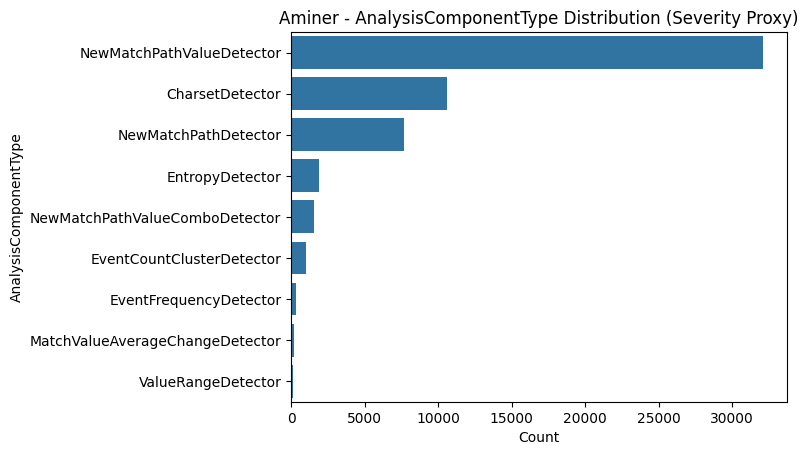

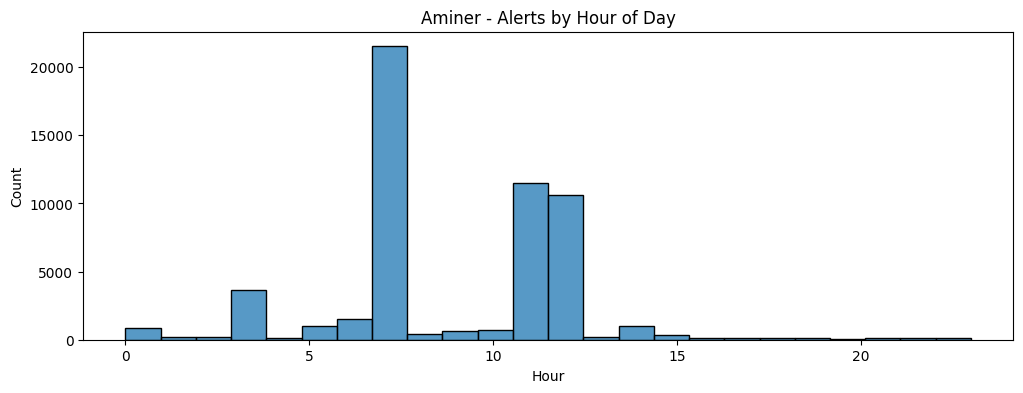


Exploring Wazuh Dataset:
Number of records: 698231
Columns: ['predecoder', 'agent', 'manager', 'rule', 'decoder', 'full_log', 'input', '@timestamp', 'location', 'id', 'data', 'GeoLocation', 'previous_output']

Top 10 Signatures (Wazuh Rule Description):
rule.description
IDS event.                                                                                            200723
Dovecot Authentication Success.                                                                       189912
Web server 400 error code.                                                                             76372
Suricata: Alert - SURICATA TLS invalid record/traffic                                                  70112
Suricata: Alert - SURICATA TLS invalid handshake message                                               70100
Suricata: Alert - ET INFO Observed DNS Query to .biz TLD                                               64655
ClamAV database update                                                    

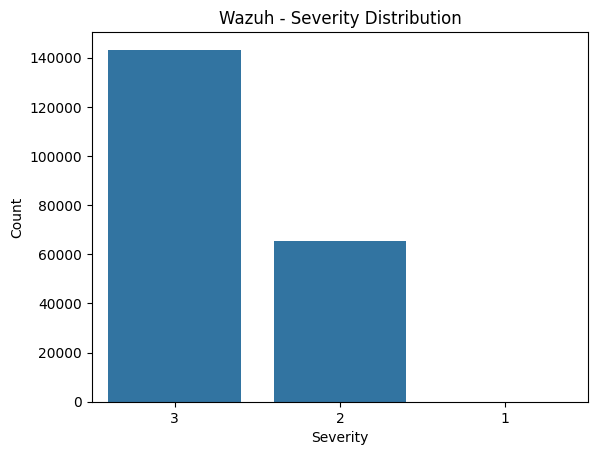

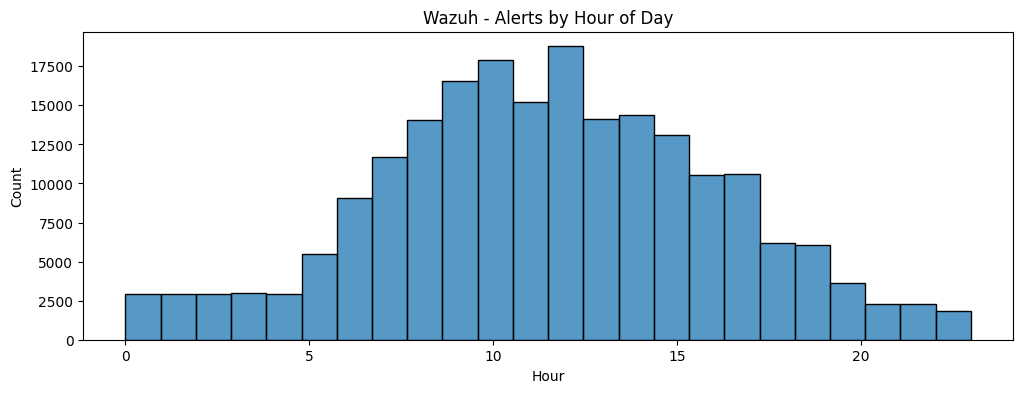

In [ ]:
def explore_alerts(df, label):
    print(f"\nExploring {label} Dataset:")
    print(f"Number of records: {len(df)}")
    print(f"Columns: {df.columns.tolist()}\n")

    df_flat = pd.json_normalize(df.to_dict('records'))

    if label == 'Aminer':
        # Top 10 signatures (Aminer):
        if 'AMiner.ID' in df_flat.columns:
            print("Top 10 Signatures (AMiner ID):")
            print(df_flat['AMiner.ID'].value_counts().head(10))

        # Severity Analysis (Aminer):
        if 'AnalysisComponent.AnalysisComponentType' in df_flat.columns:
            print("\nDistribution of AnalysisComponentType (as severity proxy):")
            print(df_flat['AnalysisComponent.AnalysisComponentType'].value_counts())

            sns.countplot(y='AnalysisComponent.AnalysisComponentType', data=df_flat, order=df_flat['AnalysisComponent.AnalysisComponentType'].value_counts().index)
            plt.title(f'{label} - AnalysisComponentType Distribution (Severity Proxy)')
            plt.xlabel('Count')
            plt.ylabel('AnalysisComponentType')
            plt.show()

        # Timestamp Analysis (Aminer):
        if 'LogData.DetectionTimestamp' in df_flat.columns:
            df_flat['LogData.DetectionTimestamp'] = df_flat['LogData.DetectionTimestamp'].apply(
                lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None
            )
            df_flat['LogData.DetectionTimestamp'] = pd.to_datetime(
                df_flat['LogData.DetectionTimestamp'], unit='s', errors='coerce'
            )
            df_flat['hour'] = df_flat['LogData.DetectionTimestamp'].dt.hour
            df_flat['date'] = df_flat['LogData.DetectionTimestamp'].dt.date

            plt.figure(figsize=(12, 4))
            sns.histplot(df_flat['hour'].dropna(), bins=24, kde=False)
            plt.title(f'{label} - Alerts by Hour of Day')
            plt.xlabel('Hour')
            plt.ylabel('Count')
            plt.show()

    elif label == 'Wazuh':
        # Top 10 signatures (Wazuh):
        if 'rule.description' in df_flat.columns:
            print("Top 10 Signatures (Wazuh Rule Description):")
            print(df_flat['rule.description'].value_counts().head(10))

        # Severity Analysis (Wazuh):
        severity_col = None
        if 'data.alert.severity' in df_flat.columns:
            severity_col = 'data.alert.severity'
        elif 'rule.level' in df_flat.columns:
            severity_col = 'rule.level'

        if severity_col:
            print(f"\nSeverity Distribution from '{severity_col}':")
            print(df_flat[severity_col].value_counts())

            sns.countplot(x=severity_col, data=df_flat)
            plt.title(f'{label} - Severity Distribution')
            plt.xlabel('Severity')
            plt.ylabel('Count')
            plt.show()

        # Timestamp Analysis (Wazuh):
        if 'data.timestamp' in df_flat.columns:
            df_flat['data.timestamp'] = pd.to_datetime(df_flat['data.timestamp'], errors='coerce')
            df_flat['hour'] = df_flat['data.timestamp'].dt.hour
            df_flat['date'] = df_flat['data.timestamp'].dt.date

            plt.figure(figsize=(12, 4))
            sns.histplot(df_flat['hour'].dropna(), bins=24, kde=False)
            plt.title(f'{label} - Alerts by Hour of Day')
            plt.xlabel('Hour')
            plt.ylabel('Count')
            plt.show()


explore_alerts(df_aminer, 'Aminer')
explore_alerts(df_wazuh, 'Wazuh')

1.2 Signature Analysis

In [ ]:
def analyze_signatures_aminer(df_aminer):
    df_flat = pd.json_normalize(df_aminer.to_dict('records'))

    if 'AMiner.ID' in df_flat.columns:
        top_signatures = df_flat['AMiner.ID'].value_counts().head(10)
        print("Top 10 Signatures (Aminer IDs):")
        print(top_signatures)

        plt.figure(figsize=(10, 5))
        sns.barplot(x=top_signatures.values, y=top_signatures.index)
        plt.title('Top 10 AMiner Signatures (IP Addresses)')
        plt.xlabel('Count')
        plt.ylabel('AMiner ID')
        plt.show()

In [ ]:
def analyze_signatures_wazuh(df_wazuh):
    df_flat = pd.json_normalize(df_wazuh.to_dict('records'))

    if 'rule.description' in df_flat.columns:
        top_descriptions = df_flat['rule.description'].value_counts().head(10)
        print("Top 10 Wazuh Rule Descriptions:")
        print(top_descriptions)

        plt.figure(figsize=(12, 6))
        sns.barplot(x=top_descriptions.values, y=top_descriptions.index)
        plt.title('Top 10 Wazuh Signatures (Rule Descriptions)')
        plt.xlabel('Count')
        plt.ylabel('Rule Description')
        plt.tight_layout()
        plt.show()

Top 10 Signatures (Aminer IDs):
AMiner.ID
192.168.2.114      11237
192.168.131.215     9455
10.35.35.206        9323
172.26.243.167      7830
192.168.104.155     3409
10.143.2.4          3304
192.168.127.254     1070
172.27.183.254       993
172.21.241.88        957
192.168.188.179      936
Name: count, dtype: int64


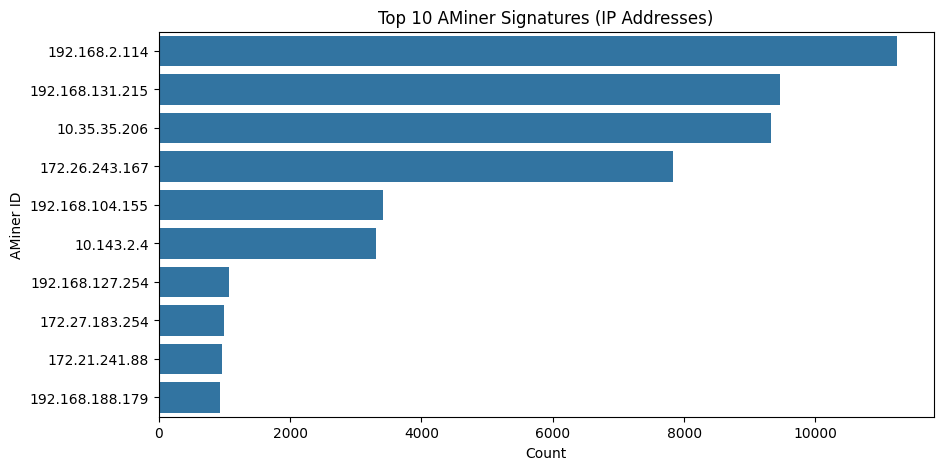

Top 10 Wazuh Rule Descriptions:
rule.description
IDS event.                                                                                            200723
Dovecot Authentication Success.                                                                       189912
Web server 400 error code.                                                                             76372
Suricata: Alert - SURICATA TLS invalid record/traffic                                                  70112
Suricata: Alert - SURICATA TLS invalid handshake message                                               70100
Suricata: Alert - ET INFO Observed DNS Query to .biz TLD                                               64655
ClamAV database update                                                                                  6135
Multiple web server 400 error codes from same source ip.                                                5868
Multiple IDS alerts for same id.                                               

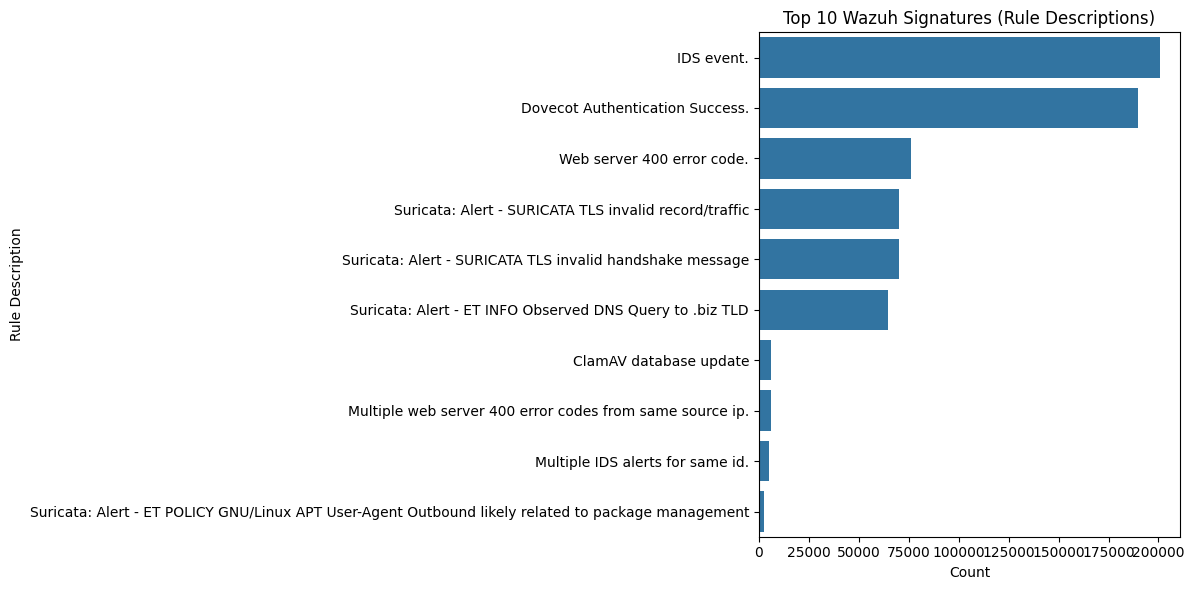

In [ ]:
analyze_signatures_aminer(df_aminer)
analyze_signatures_wazuh(df_wazuh)

-----------------------------------------------

Signature Analysis – Wazuh (Top 10 Signatures):

1. IDS Event:
- Threat Type: General Intrusion Detection Alert.
- Security Impact: May indicate suspicious network activity such as exploration or vulnerability.
- Rating: False Positive or True Positive.
- Justification: The signature is very general and covers a wide range of alerts, so it could be a false alarm if it isn't linked to a clear context.

2. Dovecot Authentication Success:
- Threat Type: Authentication Log.
- Security Impact: Nothing.
- Rating: False Positive.
- Justification: Just records a successful authentication log.

3. Web Server Error Code 400:
- Threat Type: Invalid HTTP Request.
- Security Impact: May indicate an incorrect access attempt, or an incomplete attack.
- Evaluation: False Positive or Reconnaissance.
- Justification: This could be caused by a normal user or an automated scanner, it depends on the frequency and context.

4. Suricata: Alert - Invalid Suricata TLS Log/Traffic:
- Threat Type: TLS Protocol Violation.
- Security Impact: May indicate a target for decryption, or potentially dangerous traffic.
- Evaluation: True Positive.
- Justification: This alert cannot be normal within TLS traffic, which is an advanced exploits.

5. Suricata: Alert - Invalid SURICATA TLS handshake message:
- Threat Type: TLS protocol violation.
- Security Impact: May indicate a MITM attack.
- Rating: True Positive.
- Justification: Abnormal behavior in the handshake phase is often indicative of illicit activity.

6. Suricata: Alert - ET INFO DNS query observed for .biz TLD:
- Threat Type: Possible C2 connection indicator.
- Security Impact: May indicate an attempt to communicate with suspicious domains.
- Rating: True Positive.
- Justification: Not necessarily malicious, but frequently used in public networks.

7. ClamAV Database Update:
- Threat Type: System Maintenance.
- Security Impact: Antivirus database update.
- Evaluation: False Positive.
- Justification: This signature is informational only, indicating that ClamAV is working and self-correcting.

8. Multiple web server error codes 400 from the same source IP address:
- Threat Type: Web Reconnaissance/Scanning.
- Security Impact: An attempt to discover web application vulnerabilities.
- Evaluation: True Positive.
- Justification: Prominent from the same source, often indicating a scanner or automated exploration attempt.

9. Multiple IDS alerts for the same ID:
- Threat Type: Recursive Intrusion Detection.
- Security Impact: Suspicious activity nearby.
- Evaluation: True Positive.
- Justification: The diversity and lack of indications indicate persistence of an automated identification or shutdown.

10. Suricata: Alert - ET GNU/Linux APT User-Agent Outbound Policy is likely related to package management:
- Threat Type: Policy Violation.
- Security Impact: May indicate a system update or software installation from the Internet.
- Rating: False Positive.
- Justification: The updates have been fully up-to-date.

-----------------------------------------------

Signature Analysis - AMiner (Top IPs):

1. IP: 192.168.2.114
- Type: Internal Host.
- Behavior: Top IP in terms of alert count.
- True/False Positive: True Positive.
- Justification: High frequency indicates abnormal activity.

2. IP: 192.168.131.215
- Type: Internal Device.
- Behavior: High makeup of alerts.
- True/False Positive: True Positive.
- Justification: There is a frequency indicating activation that may be malicious or unauthorized.

3. IP: 10.35.35.206
- Type: Private Network Address.
- Behavior: Appears in the third option in terms of alerts.
- True/False Positive: Context needed.
- Justification: May be part of internal or real control testing, should be linked to the type of alerts issued.

4. IP: 172.26.243.167
- Type: Internal.
- Behavior: Height Alert Actions.
- True/False Positive: True Positive.
- Justification: The IP is within the internal range but has contributed to many alerts; it should be investigated.

5. The remaining IPs (5 -10):
- Type: All internal or private IP addresses, such as 192.168.x.x, 10.x.x.x, 172.16–31.x.x
- Threat Type: Behavioral anomalies (new log paths, structural changes).
- Security Impact: Depending on the role and behavior of the host.
- Verdict: Behaviour-Dependent.
- Justification: May be true positives if these IPs are not test systems, further review advised.

-----------------------------------------------

1.3 Attack Pattern Detection

In [ ]:
# Flatten datasets
df_aminer_flat = pd.json_normalize(df_aminer.to_dict('records'))
df_wazuh_flat = pd.json_normalize(df_wazuh.to_dict('records'))

# Fix timestamps
df_aminer_flat['LogData.DetectionTimestamp'] = df_aminer_flat['LogData.DetectionTimestamp'].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None
)
df_aminer_flat['LogData.DetectionTimestamp'] = pd.to_datetime(
    df_aminer_flat['LogData.DetectionTimestamp'], unit='s', errors='coerce'
)
df_wazuh_flat['@timestamp'] = pd.to_datetime(df_wazuh_flat['@timestamp'], errors='coerce')


In [ ]:
def detect_port_scanning(df, timestamp_col, src_ip_col, port_col, label):
    print(f"\nPort Scanning Detection in {label}:")
    df = df[[timestamp_col, src_ip_col, port_col]].dropna()
    df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors='coerce')

    # Convert list port fields to string (AMiner RawLogData)
    if df[port_col].apply(type).eq(list).any():
        df[port_col] = df[port_col].astype(str)

    suspicious_ips = []
    grouped = df.groupby(src_ip_col)

    for ip, group in grouped:
        group = group.sort_values(timestamp_col)
        for i in range(len(group)):
            start_time = group.iloc[i][timestamp_col]
            window = group[
                (group[timestamp_col] >= start_time) &
                (group[timestamp_col] <= start_time + timedelta(minutes=5))
            ]
            unique_ports = window[port_col].nunique()
            if unique_ports >= 10:
                suspicious_ips.append(ip)
                break

    suspicious_ips = list(set(suspicious_ips))
    print(f"Suspicious IPs (Port Scanning): {suspicious_ips}")
    return suspicious_ips

# Run
portscan_wazuh = detect_port_scanning(df_wazuh_flat, '@timestamp', 'agent.ip', 'data.srcport', 'Wazuh')
portscan_aminer = detect_port_scanning(df_aminer_flat, 'LogData.DetectionTimestamp', 'AMiner.ID', 'LogData.RawLogData', 'AMiner')



Port Scanning Detection in Wazuh:
Suspicious IPs (Port Scanning): ['172.19.130.68', '172.17.130.37', '10.35.35.206']

Port Scanning Detection in AMiner:
Suspicious IPs (Port Scanning): ['172.17.130.196', '172.21.128.119', '192.168.104.155', '192.168.231.56', '172.27.182.4', '172.26.243.167', '172.28.255.254', '192.168.131.109', '192.168.224.185', '192.168.96.99', '10.237.1.238', '172.19.130.4', '172.17.130.37', '10.182.192.1', '172.19.130.106', '10.229.255.254', '192.168.127.254', '172.27.180.4', '10.38.243.125', '192.168.188.179', '172.28.192.7', '192.168.226.198', '10.182.194.196', '172.21.240.214', '10.38.242.195', '192.168.98.239', '172.27.183.254', '172.24.249.224', '10.35.32.1', '10.132.57.136', '10.237.0.166', '10.229.0.4', '10.182.193.78', '172.21.131.50', '10.237.2.255', '172.21.241.88', '172.19.131.174', '172.21.129.224', '10.132.56.171', '192.168.231.164', '192.168.104.218', '172.17.131.81', '10.182.194.5', '192.168.128.170', '10.132.56.1', '10.132.56.81', '192.168.255.254'

In [ ]:
def detect_brute_force(df, timestamp_col, src_ip_col, dst_ip_col, description_col, keywords, label):
    print(f"\nBrute Force Detection in {label}:")
    df = df[[timestamp_col, src_ip_col, dst_ip_col, description_col]].dropna()
    df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors='coerce')

    brute_ips = []
    df['combined'] = df[src_ip_col].astype(str) + '->' + df[dst_ip_col].astype(str)
    filtered = df[df[description_col].str.contains('|'.join(keywords), case=False, na=False)]

    for pair, group in filtered.groupby('combined'):
        group = group.sort_values(timestamp_col)
        for i in range(len(group)):
            start = group.iloc[i][timestamp_col]
            window = group[
                (group[timestamp_col] >= start) &
                (group[timestamp_col] <= start + timedelta(minutes=10))
            ]
            if len(window) >= 5:
                brute_ips.append(pair)
                break

    brute_ips = list(set(brute_ips))
    print(f"Suspicious IP Pairs (Brute Force): {brute_ips}")
    return brute_ips

# Run on Wazuh
brute_wazuh = detect_brute_force(df_wazuh_flat, '@timestamp', 'agent.ip', 'manager.name', 'rule.description', ['authentication failure', 'failed login'], 'Wazuh')

# Run on AMiner
brute_aminer = detect_brute_force(df_aminer_flat, 'LogData.DetectionTimestamp', 'AMiner.ID', 'AnalysisComponent.AnalysisComponentName', 'AnalysisComponent.Message', ['login', 'failed', 'denied', 'unauthorized'], 'AMiner')



Brute Force Detection in Wazuh:
Suspicious IP Pairs (Brute Force): []

Brute Force Detection in AMiner:
Suspicious IP Pairs (Brute Force): []


In [ ]:
def detect_web_attacks(df, timestamp_col, ip_col, description_col, label):
    print(f"\nWeb Application Attack Detection in {label}:")
    df = df[[timestamp_col, ip_col, description_col]].dropna()
    df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors='coerce')

    keywords = ['sql injection', 'xss', 'directory traversal']
    filtered = df[df[description_col].str.contains('|'.join(keywords), case=False, na=False)]
    attackers = filtered[ip_col].unique().tolist()

    print(f"Web Attack Sources: {attackers}")
    return attackers

web_attacks_wazuh = detect_web_attacks(df_wazuh_flat, '@timestamp', 'agent.ip', 'rule.description', 'Wazuh')
web_attacks_aminer = detect_web_attacks(df_aminer_flat, 'LogData.DetectionTimestamp', 'AMiner.ID', 'AnalysisComponent.Message', 'AMiner')



Web Application Attack Detection in Wazuh:
Web Attack Sources: []

Web Application Attack Detection in AMiner:
Web Attack Sources: []


In [ ]:
def detect_data_exfiltration(df, timestamp_col, ip_col, raw_col, label):
    print(f"\nData Exfiltration Detection in {label}:")
    df = df[[timestamp_col, ip_col, raw_col]].dropna()
    df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors='coerce')

    suspicious = []
    dns_keywords = ['dns', 'lookup', 'query']
    for ip, group in df.groupby(ip_col):
        count = group[raw_col].str.contains('|'.join(dns_keywords), case=False, na=False).sum()
        if count >= 10:
            suspicious.append(ip)

    print(f"Suspicious IPs (Data Exfiltration via DNS): {suspicious}")
    return suspicious

# Run detection
exfil_wazuh = detect_data_exfiltration(df_wazuh_flat, '@timestamp', 'agent.ip', 'full_log', 'Wazuh')
exfil_aminer = detect_data_exfiltration(df_aminer_flat, 'LogData.DetectionTimestamp', 'AMiner.ID', 'LogData.RawLogData', 'AMiner')



Data Exfiltration Detection in Wazuh:
Suspicious IPs (Data Exfiltration via DNS): ['10.132.56.1', '10.132.56.81', '10.182.192.1', '10.182.193.78', '10.229.0.4', '10.237.1.238', '10.237.2.255', '10.35.32.1', '10.35.35.206', '10.38.243.125', '10.38.243.24', '172.17.130.196', '172.19.128.1', '172.24.249.224', '172.27.180.4', '192.168.104.218', '192.168.128.1', '192.168.131.109', '192.168.2.114']

Data Exfiltration Detection in AMiner:
Suspicious IPs (Data Exfiltration via DNS): []


In [ ]:
print("\nSummary of Detected Attacks:")
print("\n Port Scanning:")
print(" - Wazuh:", portscan_wazuh)
print(" - AMiner:", portscan_aminer)
print("\n Brute Force:")
print(" - Wazuh:", brute_wazuh)
print(" - AMiner:", brute_aminer)
print("\n Web App Attacks:")
print(" - Wazuh:", web_attacks_wazuh)
print(" - AMiner:", web_attacks_aminer)
print("\n Data Exfiltration:")
print(" - Wazuh:", exfil_wazuh)
print(" - AMiner:", exfil_aminer)



Summary of Detected Attacks:

 Port Scanning:
 - Wazuh: ['172.19.130.68', '172.17.130.37', '10.35.35.206']
 - AMiner: ['172.17.130.196', '172.21.128.119', '192.168.104.155', '192.168.231.56', '172.27.182.4', '172.26.243.167', '172.28.255.254', '192.168.131.109', '192.168.224.185', '192.168.96.99', '10.237.1.238', '172.19.130.4', '172.17.130.37', '10.182.192.1', '172.19.130.106', '10.229.255.254', '192.168.127.254', '172.27.180.4', '10.38.243.125', '192.168.188.179', '172.28.192.7', '192.168.226.198', '10.182.194.196', '172.21.240.214', '10.38.242.195', '192.168.98.239', '172.27.183.254', '172.24.249.224', '10.35.32.1', '10.132.57.136', '10.237.0.166', '10.229.0.4', '10.182.193.78', '172.21.131.50', '10.237.2.255', '172.21.241.88', '172.19.131.174', '172.21.129.224', '10.132.56.171', '192.168.231.164', '192.168.104.218', '172.17.131.81', '10.182.194.5', '192.168.128.170', '10.132.56.1', '10.132.56.81', '192.168.255.254', '172.19.130.68', '192.168.131.215', '192.168.231.254', '172.19.12

--------------------------------------------------------------------------------

**Part 2: Alert Correlation and Visualization:**

2.1 Temporal Analysis:

In [ ]:
# get the ip column and concat it with original data

ip_wazuh = df_wazuh['agent'].str.get('ip')
df_wazuh['agent_ip'] = ip_wazuh

ip_AMiner = df_aminer['AMiner'].str.get('ID')
df_aminer['agent_ip'] = ip_AMiner

# Extract the timestamp from the list before converting to datetime
df_aminer['Timestamp'] = df_aminer['LogData'].apply(lambda x: x.get('DetectionTimestamp')[0] if x and x.get('DetectionTimestamp') else None)
df_aminer['Timestamp'] = pd.to_datetime(df_aminer['Timestamp'], unit='s', errors='coerce')
df_aminer['Timestamp'] = df_aminer['Timestamp'].dt.floor('5min')

df_wazuh['time_clock'] = pd.to_datetime(df_wazuh['@timestamp'])
df_wazuh['time_bucket'] = df_wazuh['time_clock'].dt.floor('5min')

correlated_alerts_wazuh = df_wazuh.groupby(['agent_ip', 'time_bucket']).size().reset_index(name='alert_count')
print('The unusual actions for wazuh data set is : \n')
display(correlated_alerts_wazuh)

correlated_alerts_aminer = df_aminer.groupby(['agent_ip', 'Timestamp']).size().reset_index(name='alert_count')
print('\nThe unusual actions for aminer data set is : \n')
display(correlated_alerts_aminer)

The unusual actions for wazuh data set is : 



,agent_ip,time_bucket,alert_count
0,10.132.56.1,2022-01-19 01:00:00+00:00,16
1,10.132.56.1,2022-01-19 03:40:00+00:00,16
2,10.132.56.1,2022-01-19 03:55:00+00:00,28
3,10.132.56.1,2022-01-19 04:00:00+00:00,2
4,10.132.56.1,2022-01-19 04:55:00+00:00,8
...,...,...,...
19446,192.168.99.0,2022-01-23 19:25:00+00:00,1
19447,192.168.99.0,2022-01-23 20:25:00+00:00,1
19448,192.168.99.0,2022-01-23 21:25:00+00:00,1
19449,192.168.99.0,2022-01-23 22:25:00+00:00,1



The unusual actions for aminer data set is : 



,agent_ip,Timestamp,alert_count
0,10.132.56.1,2022-01-19 00:00:00,4
1,10.132.56.1,2022-01-19 00:05:00,3
2,10.132.56.1,2022-01-19 00:15:00,2
3,10.132.56.1,2022-01-19 01:00:00,4
4,10.132.56.1,2022-01-19 02:55:00,1
...,...,...,...
2748,192.168.98.239,2022-01-19 08:00:00,1
2749,192.168.98.239,2022-01-21 07:00:00,1
2750,192.168.98.239,2022-01-23 12:10:00,40
2751,192.168.99.0,2022-01-19 00:05:00,4


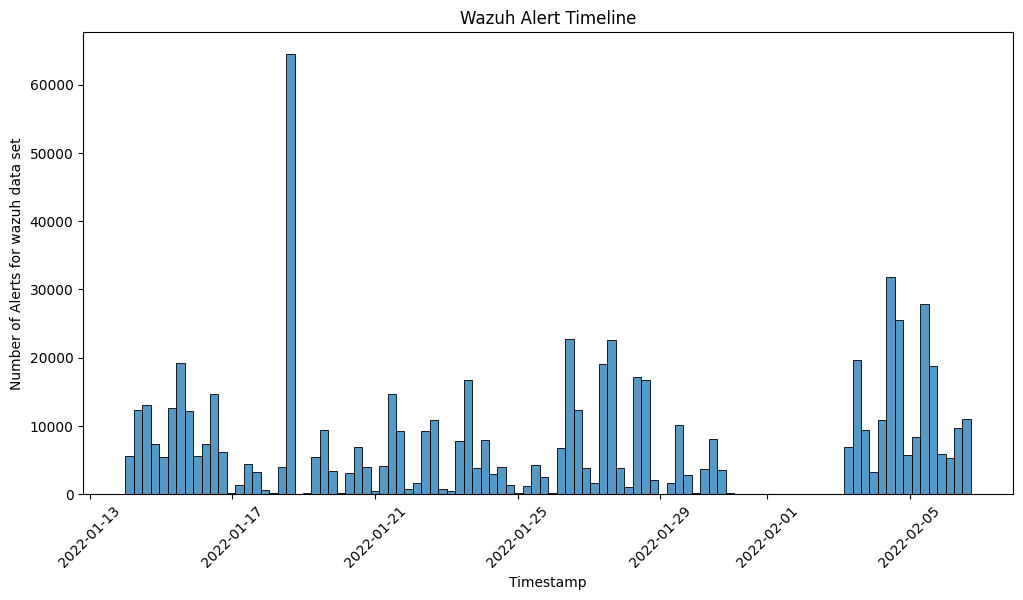

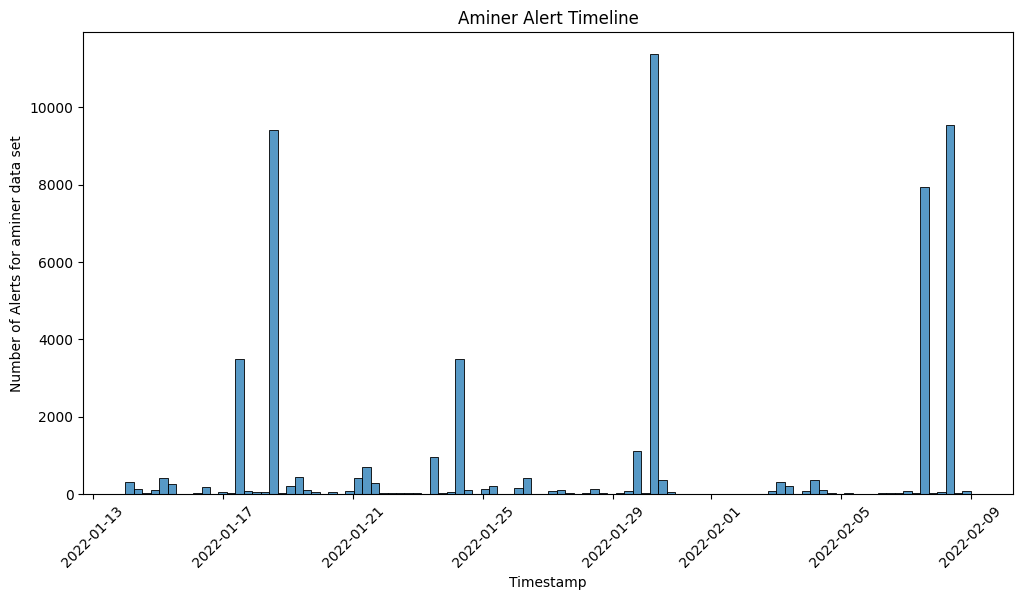

In [ ]:
# Create a timeline visualization of alerts
alert_time = pd.to_datetime(df_wazuh['@timestamp'])
plt.figure(figsize=(12, 6))
sns.histplot(alert_time, bins=100)
plt.title('Wazuh Alert Timeline')
plt.xlabel('Timestamp')
plt.ylabel('Number of Alerts for wazuh data set')
plt.xticks(rotation=45)
plt.show()

df_aminer['Timestamp'] = df_aminer['LogData'].apply(lambda x: x.get('DetectionTimestamp')[0] if x and x.get('DetectionTimestamp') else None)
df_aminer['Timestamp'] = pd.to_datetime(df_aminer['Timestamp'], unit='s', errors='coerce')

alert_time = pd.to_datetime(df_aminer['Timestamp'])
plt.figure(figsize=(12, 6))
sns.histplot(alert_time, bins=100)
plt.title('Aminer Alert Timeline')
plt.xlabel('Timestamp')
plt.ylabel('Number of Alerts for aminer data set')
plt.xticks(rotation=45)
plt.show()

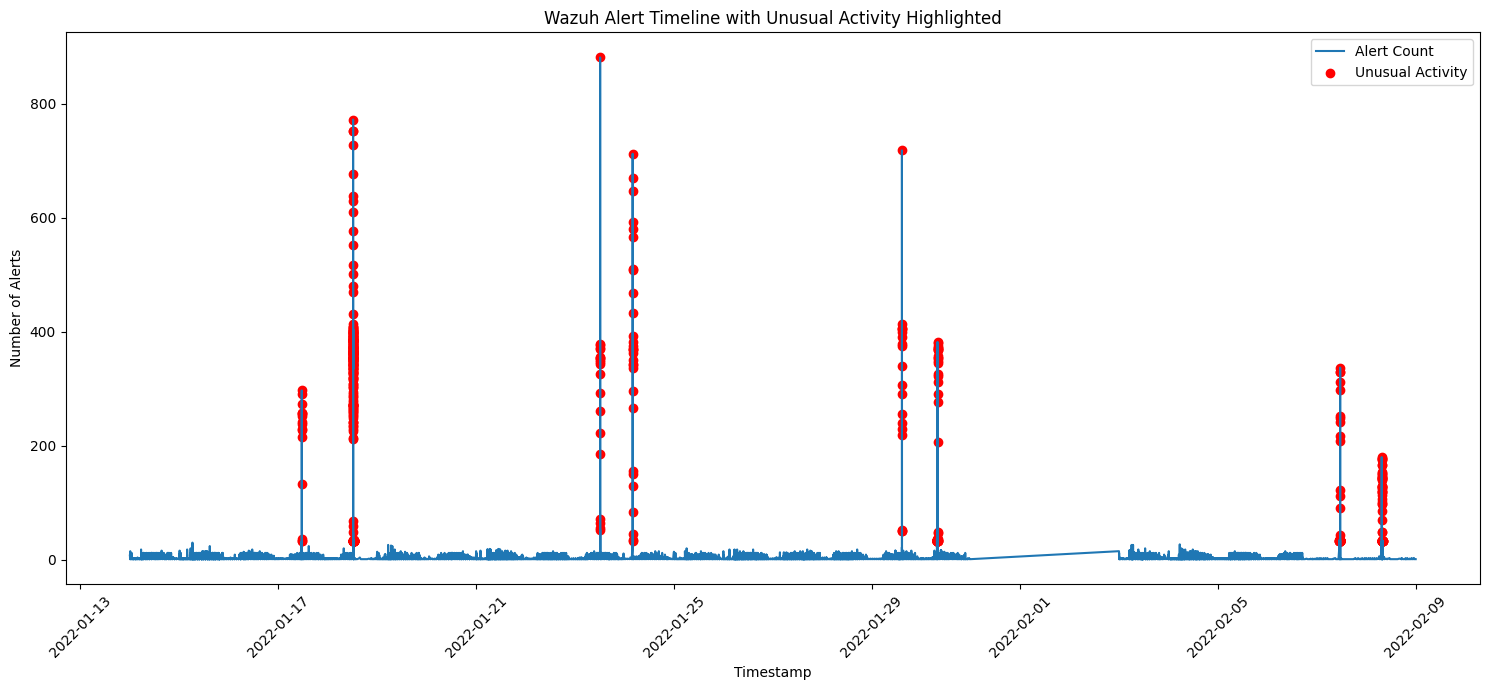

In [ ]:
#Identify time periods with unusual alert activity
alert_time_wazuh = pd.to_datetime(df_wazuh['@timestamp']).dt.tz_convert('UTC')
alert_time_aminer = pd.to_datetime(df_aminer['Timestamp']).dt.tz_localize('UTC')
alert_time = pd.concat([alert_time_wazuh, alert_time_aminer])
alert_counts = alert_time.value_counts().sort_index()

mean_alerts = alert_counts.mean()
std_alerts = alert_counts.std()
threshold = mean_alerts + 2 * std_alerts

unusual_periods = alert_counts[alert_counts > threshold]

plt.figure(figsize=(15, 7))
plt.plot(alert_counts.index, alert_counts.values, label='Alert Count')
plt.scatter(unusual_periods.index, unusual_periods.values, color='red', label='Unusual Activity')
plt.title('Wazuh Alert Timeline with Unusual Activity Highlighted')
plt.xlabel('Timestamp')
plt.ylabel('Number of Alerts')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# get the ip column and concat it with original data

ip_wazuh = df_wazuh['agent'].str.get('ip')
df_wazuh['agent_ip'] = ip_wazuh

ip_AMiner = df_aminer['AMiner'].str.get('ID')
df_aminer['agent_ip'] = ip_AMiner

# Extract the timestamp from the list before converting to datetime
df_aminer['Timestamp'] = df_aminer['LogData'].apply(lambda x: x.get('DetectionTimestamp')[0] if x and x.get('DetectionTimestamp') else None)
df_aminer['Timestamp'] = pd.to_datetime(df_aminer['Timestamp'], unit='s', errors='coerce')
df_aminer['Timestamp'] = df_aminer['Timestamp'].dt.floor('5min')

df_wazuh['time_clock'] = pd.to_datetime(df_wazuh['@timestamp'])
df_wazuh['time_bucket'] = df_wazuh['time_clock'].dt.floor('5min')

correlated_alerts_wazuh = df_wazuh.groupby(['agent_ip', 'time_bucket']).size().reset_index(name='alert_count')
print('The unusual actions for wazuh data set is : \n')
display(correlated_alerts_wazuh)

correlated_alerts_aminer = df_aminer.groupby(['agent_ip', 'Timestamp']).size().reset_index(name='alert_count')
print('\nThe unusual actions for aminer data set is : \n')
display(correlated_alerts_aminer)

The unusual actions for wazuh data set is : 



,agent_ip,time_bucket,alert_count
0,10.132.56.1,2022-01-19 01:00:00+00:00,16
1,10.132.56.1,2022-01-19 03:40:00+00:00,16
2,10.132.56.1,2022-01-19 03:55:00+00:00,28
3,10.132.56.1,2022-01-19 04:00:00+00:00,2
4,10.132.56.1,2022-01-19 04:55:00+00:00,8
...,...,...,...
19446,192.168.99.0,2022-01-23 19:25:00+00:00,1
19447,192.168.99.0,2022-01-23 20:25:00+00:00,1
19448,192.168.99.0,2022-01-23 21:25:00+00:00,1
19449,192.168.99.0,2022-01-23 22:25:00+00:00,1



The unusual actions for aminer data set is : 



,agent_ip,Timestamp,alert_count
0,10.132.56.1,2022-01-19 00:00:00,4
1,10.132.56.1,2022-01-19 00:05:00,3
2,10.132.56.1,2022-01-19 00:15:00,2
3,10.132.56.1,2022-01-19 01:00:00,4
4,10.132.56.1,2022-01-19 02:55:00,1
...,...,...,...
2748,192.168.98.239,2022-01-19 08:00:00,1
2749,192.168.98.239,2022-01-21 07:00:00,1
2750,192.168.98.239,2022-01-23 12:10:00,40
2751,192.168.99.0,2022-01-19 00:05:00,4


2.2 Network Entity Analysis:

In [ ]:
# Identify the top source and destination IPs involved in alerts
top_sources_wazuh = df_wazuh['agent_ip'].value_counts().head(10)
top_destinations_wazuh = df_wazuh['manager'].str.get('name').value_counts().head(10)

top_sources_aminer = df_aminer['agent_ip'].value_counts().head(10)
top_destinations_aminer = df_aminer['AnalysisComponent'].str.get('AnalysisComponentName').value_counts().head(10)

print("Top Source IPs (Wazuh):")
print(top_sources_wazuh)
print("\nTop Destination IPs:")
print(top_destinations_wazuh)

print("\nTop Source IPs (AMiner):")
print(top_sources_aminer)
print("\nTop Destination IPs:")
print(top_destinations_aminer)

Top Source IPs (Wazuh):
agent_ip
10.35.35.206       64284
10.229.0.4         43963
172.27.180.4       40942
10.182.194.5       39758
192.168.128.1      37857
10.38.243.24       30767
10.132.56.1        30252
10.38.242.195      30001
192.168.131.109    29420
192.168.104.218    25756
Name: count, dtype: int64

Top Destination IPs:
manager
wazuh.manager    698231
Name: count, dtype: int64

Top Source IPs (AMiner):
agent_ip
192.168.2.114      11237
192.168.131.215     9455
10.35.35.206        9323
172.26.243.167      7830
192.168.104.155     3409
10.143.2.4          3304
192.168.127.254     1070
172.27.183.254       993
172.21.241.88        957
192.168.188.179      936
Name: count, dtype: int64

Top Destination IPs:
AnalysisComponent
AMiner: New request method in Apache Access log.              27342
AMiner: New characters in Apache Access request.              10366
AMiner: New event type.                                        7660
AMiner: New status code in Apache Access log.           

In [ ]:
# Create a network graph showing relationships between source and destination IPs

# Prepare data for network graph (using Wazuh data as it has source and destination IPs)
# We need to count the number of alerts between each source-destination pair
df_wazuh_flat['source_ip'] = df_wazuh_flat['agent.ip']
df_wazuh_flat['destination_ip'] = df_wazuh_flat['manager.name']

df_aminer_flat['source_ip'] = df_aminer_flat['AMiner.ID']
df_aminer_flat['destination_ip'] = df_aminer_flat['AnalysisComponent.AnalysisComponentName']

# Filter out rows with missing source or destination IPs
df_graph_wazuh = df_wazuh_flat.dropna(subset=['source_ip', 'destination_ip'])
df_graph_aminer = df_aminer_flat.dropna(subset=['source_ip', 'destination_ip'])

# Count the occurrences of each source-destination pair
edge_list_wazuh = df_graph_wazuh.groupby(['source_ip', 'destination_ip']).size().reset_index(name='weight')
edge_list_aminer = df_graph_aminer.groupby(['source_ip', 'destination_ip']).size().reset_index(name='weight')

print("Edge List for Wazuh:")
display(edge_list_wazuh.head())

print("\nEdge List for AMiner:")
display(edge_list_aminer.head())

Edge List for Wazuh:


,source_ip,destination_ip,weight
0,10.132.56.1,wazuh.manager,30252
1,10.132.56.171,wazuh.manager,19626
2,10.132.56.204,wazuh.manager,137
3,10.132.56.81,wazuh.manager,14904
4,10.132.57.136,wazuh.manager,3695



Edge List for AMiner:


,source_ip,destination_ip,weight
0,10.132.56.1,AMiner: High entropy in DNS domain.,241
1,10.132.56.1,AMiner: New event type.,2
2,10.132.56.1,AMiner: New ip address in DNS logs.,19
3,10.132.56.1,AMiner: New query record in DNS logs.,1
4,10.132.56.1,AMiner: New service_start parameter combinatio...,1


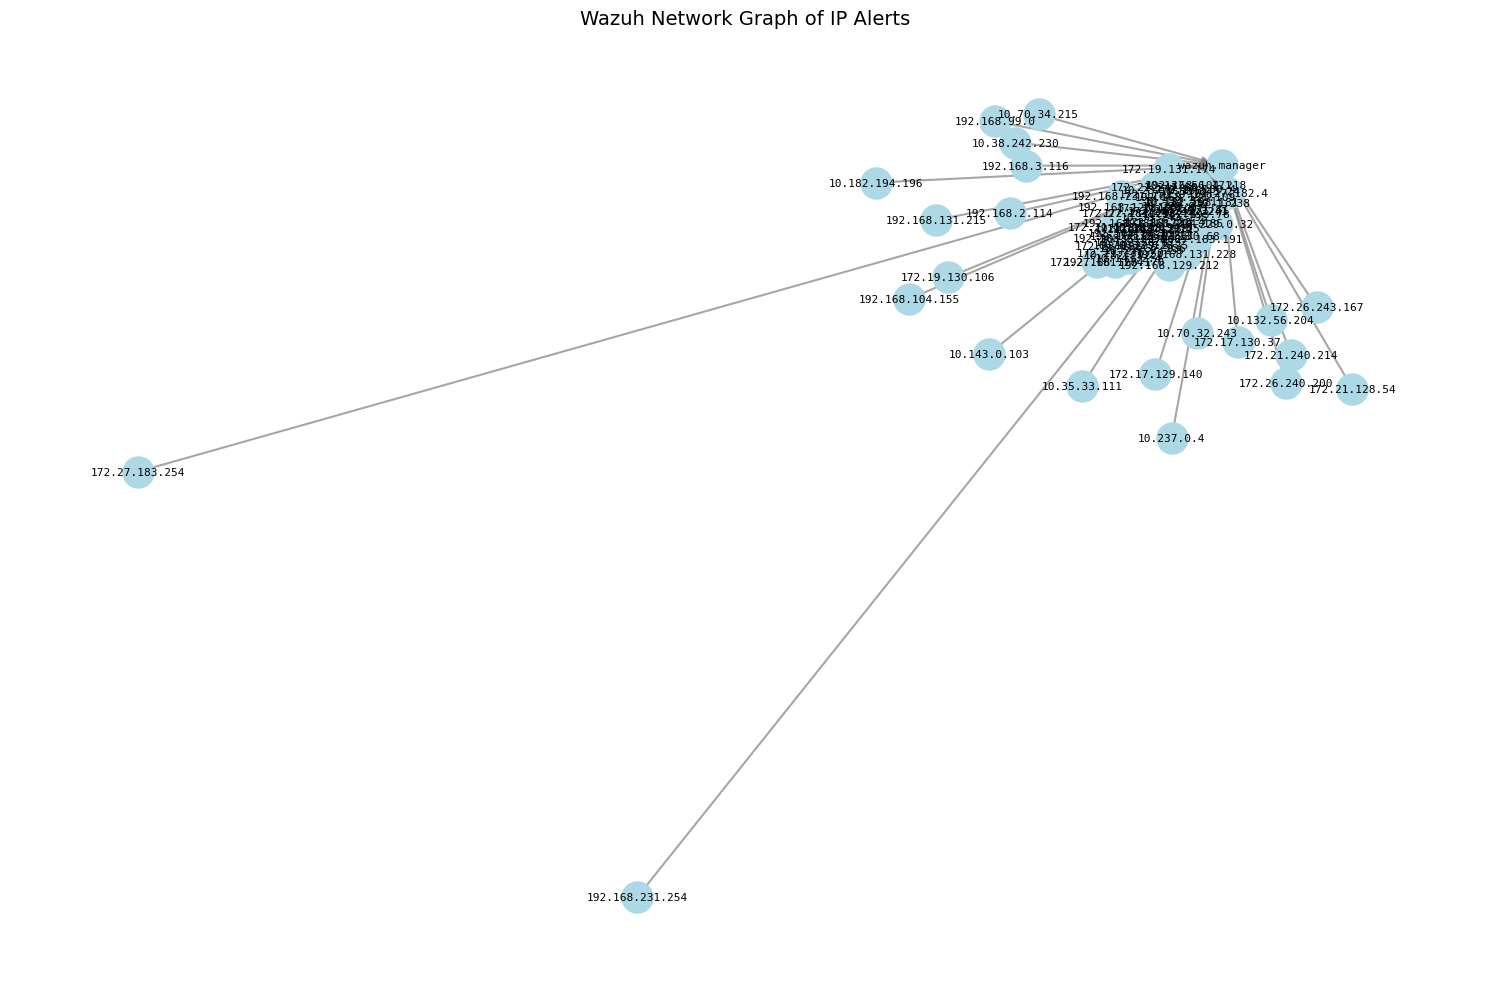

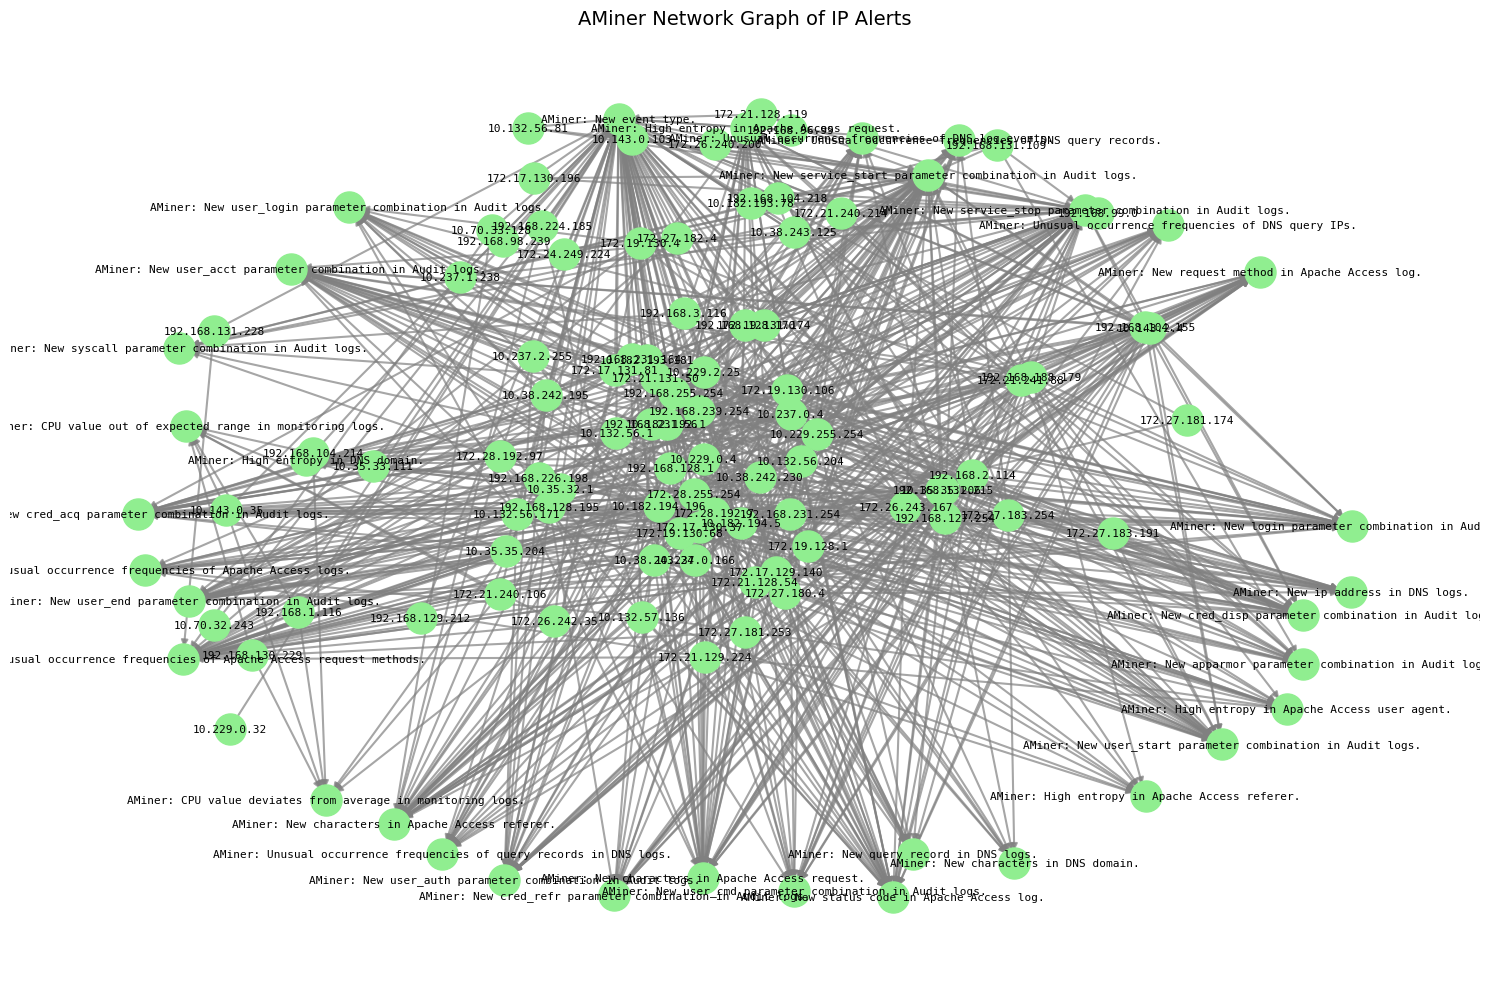

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graphs for each dataset
G_wazuh = nx.DiGraph()
for index, row in edge_list_wazuh.iterrows():
    G_wazuh.add_edge(row['source_ip'], row['destination_ip'], weight=row['weight'])

G_aminer = nx.DiGraph()
for index, row in edge_list_aminer.iterrows():
    G_aminer.add_edge(row['source_ip'], row['destination_ip'], weight=row['weight'])


# Graph layout for each graph
pos_wazuh = nx.spring_layout(G_wazuh, k=1.8, iterations=100)
pos_aminer = nx.spring_layout(G_aminer, k=1.8, iterations=100)


# Draw the Wazuh graph
plt.figure(figsize=(15, 10))
nx.draw_networkx_nodes(G_wazuh, pos_wazuh, node_size=500, node_color='lightblue')
nx.draw_networkx_edges(G_wazuh, pos_wazuh, width=1.5, alpha=0.7, edge_color='gray', arrows=True)
nx.draw_networkx_labels(G_wazuh, pos_wazuh, font_size=8, font_family="monospace")
plt.title("Wazuh Network Graph of IP Alerts", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

# Draw the AMiner graph
plt.figure(figsize=(15, 10))
nx.draw_networkx_nodes(G_aminer, pos_aminer, node_size=500, node_color='lightgreen')
nx.draw_networkx_edges(G_aminer, pos_aminer, width=1.5, alpha=0.7, edge_color='gray', arrows=True)
nx.draw_networkx_labels(G_aminer, pos_aminer, font_size=8, font_family="monospace")
plt.title("AMiner Network Graph of IP Alerts", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Count alerts per source IP (Potentional attackers):
attacker_count_aminer = df_aminer_flat['source_ip'].value_counts().reset_index()
attacker_count_aminer.columns = ['Source IP', 'Alert Count']

# Count alerts per source IP (Potentional victims):
victims_count_aminer = df_aminer_flat['destination_ip'].value_counts().reset_index()
victims_count_aminer.columns = ['Destination IP', 'Alert Count']

print("Top Potentional Attackers (AMiner):")
print(attacker_count_aminer.head(10))
print("\nTop Potentional Victims (AMiner):")
print(victims_count_aminer.head(10))

Top Potentional Attackers (AMiner):
         Source IP  Alert Count
0    192.168.2.114        11237
1  192.168.131.215         9455
2     10.35.35.206         9323
3   172.26.243.167         7830
4  192.168.104.155         3409
5       10.143.2.4         3304
6  192.168.127.254         1070
7   172.27.183.254          993
8    172.21.241.88          957
9  192.168.188.179          936

Top Potentional Victims (AMiner):
                                      Destination IP  Alert Count
0   AMiner: New request method in Apache Access log.        27342
1   AMiner: New characters in Apache Access request.        10366
2                            AMiner: New event type.         7660
3      AMiner: New status code in Apache Access log.         3220
4                AMiner: High entropy in DNS domain.         1781
5                AMiner: New ip address in DNS logs.         1569
6  AMiner: Unusual occurrence frequencies of DNS ...          421
7  AMiner: New user_acct parameter combination in

In [ ]:
# Count alerts per source IP (Potentional attackers):
attacker_count_wazuh = df_wazuh_flat['source_ip'].value_counts().reset_index()
attacker_count_wazuh.columns = ['Source IP', 'Alert Count']

# Count alerts per source IP (Potentional victims):
victims_count_wazuh = df_wazuh_flat['destination_ip'].value_counts().reset_index()
victims_count_wazuh.columns = ['Destination IP', 'Alert Count']

print("Top Potentional Attackers (wazuh):")
print(attacker_count_wazuh.head(10))
print("\nTop Potentional Victims (wazuh):")
print(victims_count_wazuh.head(10))

Top Potentional Attackers (wazuh):
         Source IP  Alert Count
0     10.35.35.206        64284
1       10.229.0.4        43963
2     172.27.180.4        40942
3     10.182.194.5        39758
4    192.168.128.1        37857
5     10.38.243.24        30767
6      10.132.56.1        30252
7    10.38.242.195        30001
8  192.168.131.109        29420
9  192.168.104.218        25756

Top Potentional Victims (wazuh):
  Destination IP  Alert Count
0  wazuh.manager       698231


2.3 Alert Severity Analysis:

In [ ]:
# Categorize alerts by severity level
print("\n Port Scanning:")
print(" - Wazuh:", portscan_wazuh)
print(f" - The lenght of portscan wazuh :  {len(portscan_wazuh)} \n")
print(" - AMiner:", portscan_aminer)
print(f" - The lenght of portscan aminer :  {len(portscan_aminer)} \n")
print("\n Brute Force:")
print(" - Wazuh:", brute_wazuh)
print(f" - The lenght of brute wazuh :  {len(brute_wazuh)} \n")
print(" - AMiner:", brute_aminer)
print(f" - The lenght of brute aminer :  {len(brute_aminer)} \n")
print("\n Web App Attacks:")
print(" - Wazuh:", web_attacks_wazuh)
print(f" - The lenght of web attacks wazuh :  {len(web_attacks_wazuh)} \n")
print(" - AMiner:", web_attacks_aminer)
print(f" - The lenght of web attacks aminer :  {len(web_attacks_aminer)} \n")
print("\n Data Exfiltration:")
print(" - Wazuh:", exfil_wazuh)
print(f" - The lenght of exfil wazuh :  {len(exfil_wazuh)} \n")
print(" - AMiner:", exfil_aminer)
print(f" - The lenght of exfil aminer :  {len(exfil_aminer)} \n")


 Port Scanning:
 - Wazuh: ['172.19.130.68', '172.17.130.37', '10.35.35.206']
 - The lenght of portscan wazuh :  3 

 - AMiner: ['172.17.130.196', '172.21.128.119', '192.168.104.155', '192.168.231.56', '172.27.182.4', '172.26.243.167', '172.28.255.254', '192.168.131.109', '192.168.224.185', '192.168.96.99', '10.237.1.238', '172.19.130.4', '172.17.130.37', '10.182.192.1', '172.19.130.106', '10.229.255.254', '192.168.127.254', '172.27.180.4', '10.38.243.125', '192.168.188.179', '172.28.192.7', '192.168.226.198', '10.182.194.196', '172.21.240.214', '10.38.242.195', '192.168.98.239', '172.27.183.254', '172.24.249.224', '10.35.32.1', '10.132.57.136', '10.237.0.166', '10.229.0.4', '10.182.193.78', '172.21.131.50', '10.237.2.255', '172.21.241.88', '172.19.131.174', '172.21.129.224', '10.132.56.171', '192.168.231.164', '192.168.104.218', '172.17.131.81', '10.182.194.5', '192.168.128.170', '10.132.56.1', '10.132.56.81', '192.168.255.254', '172.19.130.68', '192.168.131.215', '192.168.231.254', '

The most danger attacks is : Port Scanning (high risk) because there are too many attacks on it -> 63 attacks.

Then we have the Data : Exfiltration (medium risk) -> 19 attacks only.

Then we have the Wep App attacks and Brute Force (low risk) -> 0 attacks

/tmp/ipython-input-3128867763.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x, y=y, palette=['red', 'green', 'blue', 'yellow'])


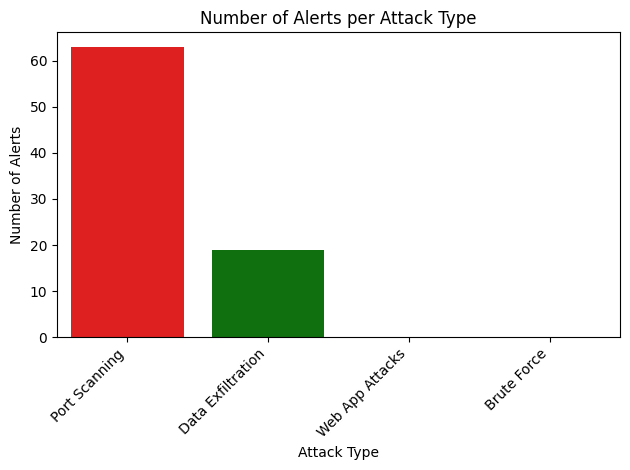

In [ ]:
# Create visualizations showing the distribution of severity levels
x = ['Port Scanning', 'Data Exfiltration', 'Web App Attacks', 'Brute Force']
y = [len(portscan_wazuh) + len(portscan_aminer), len(exfil_wazuh) + len(exfil_aminer),\
     len(web_attacks_wazuh) + len(web_attacks_wazuh), len(brute_wazuh) + len(brute_aminer)]
sns.barplot(x=x, y=y, palette=['red', 'green', 'blue', 'yellow'])
plt.title('Number of Alerts per Attack Type')
plt.xlabel('Attack Type')
plt.ylabel('Number of Alerts')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Develop a risk score formula that considers:
#  • Alert severity
#  • Frequency of alerts
#  • Temporal concentration
#  • Involvement in known attack patterns

aminer_ip_frequency = df_aminer_flat['AMiner.ID'].value_counts().rename('aminer_frequency')
wazuh_ip_frequency = df_wazuh_flat['agent.ip'].value_counts().rename('wazuh_frequency')

In [ ]:
# 1. Define AMiner severity mapping
aminer_severity_map = {
    'NewMatchPathDetector': 1,
    'NewMatchPathValueComboDetector': 2,
    'CharsetDetector': 3,
    'EntropyDetector': 4,
    'ValueRangeDetector': 5,
    'MatchValueAverageChangeDetector': 6,
    'EventFrequencyDetector': 7,
    'EventCountClusterDetector': 8,
}

# 2. Define Wazuh severity mapping
wazuh_severity_map_level = {
    1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13, 14: 14, 15: 15
}
wazuh_severity_map_alert = {
    1: 4, 2: 7, 3: 10, 4: 13, 5: 15
} # Mapping data.alert.severity to a scale similar to rule.level

# 3. Apply AMiner severity mapping
df_aminer_flat['aminer_severity'] = df_aminer_flat['AnalysisComponent.AnalysisComponentType'].map(aminer_severity_map).fillna(0)

# 4. Apply Wazuh severity mapping
# Prioritize data.alert.severity
df_wazuh_flat['wazuh_severity'] = df_wazuh_flat['data.alert.severity'].map(wazuh_severity_map_alert)
# Fill missing values with rule.level mapping
df_wazuh_flat['wazuh_severity'] = df_wazuh_flat['wazuh_severity'].fillna(df_wazuh_flat['rule.level'].map(wazuh_severity_map_level)).fillna(0)

# 5. Calculate the average severity score for each IP
aminer_avg_severity = df_aminer_flat.groupby('AMiner.ID')['aminer_severity'].mean().rename('aminer_avg_severity')
wazuh_avg_severity = df_wazuh_flat.groupby('agent.ip')['wazuh_severity'].mean().rename('wazuh_avg_severity')

# Display the average severity scores
print("Average AMiner Severity per IP:")
display(aminer_avg_severity.head())

print("\nAverage Wazuh Severity per IP:")
display(wazuh_avg_severity.head())

Average AMiner Severity per IP:


,aminer_avg_severity
AMiner.ID,
10.132.56.1,4.576471
10.132.56.171,1.861257
10.132.56.204,1.714286
10.132.56.81,1.071429
10.132.57.136,3.622951



Average Wazuh Severity per IP:


,wazuh_avg_severity
agent.ip,
10.132.56.1,4.554740
10.132.56.171,3.009121
10.132.56.204,4.802920
10.132.56.81,4.535963
10.132.57.136,4.541813


In [ ]:
# Combine all unique IPs from both datasets
all_ips = pd.Index(df_aminer_flat['AMiner.ID']).union(df_wazuh_flat['agent.ip'])

# Create a DataFrame to hold the combined analysis data, indexed by IP
ip_analysis = pd.DataFrame(index=all_ips)

# Add frequency data, filling with 0 for IPs not present in a dataset
ip_analysis = pd.merge(ip_analysis, aminer_ip_frequency, left_index=True, right_index=True, how='left').fillna(0)
ip_analysis = pd.merge(ip_analysis, wazuh_ip_frequency, left_index=True, right_index=True, how='left').fillna(0)

# Add temporal standard deviation data, filling with 0
# Ensure 'aminer_temporal' and 'wazuh_temporal' are defined - re-running the temporal analysis step if needed
# Temporal concentration analysis for AMiner
aminer_temporal = df_aminer_flat.groupby(['AMiner.ID', df_aminer_flat['LogData.DetectionTimestamp'].dt.hour]).size().unstack(fill_value=0)
aminer_temporal['aminer_temporal_std'] = aminer_temporal.std(axis=1)

# Temporal concentration analysis for Wazuh
wazuh_temporal = df_wazuh_flat.groupby(['agent.ip', df_wazuh_flat['@timestamp'].dt.hour]).size().unstack(fill_value=0)
wazuh_temporal['wazuh_temporal_std'] = wazuh_temporal.std(axis=1)


ip_analysis = pd.merge(ip_analysis, aminer_temporal[['aminer_temporal_std']], left_index=True, right_index=True, how='left').fillna(0)
ip_analysis = pd.merge(ip_analysis, wazuh_temporal[['wazuh_temporal_std']], left_index=True, right_index=True, how='left').fillna(0)


# Add average severity scores, filling with 0
ip_analysis = pd.merge(ip_analysis, aminer_avg_severity, left_index=True, right_index=True, how='left').fillna(0)
ip_analysis = pd.merge(ip_analysis, wazuh_avg_severity, left_index=True, right_index=True, how='left').fillna(0)

# Create a set of all IPs involved in any detected attack pattern
all_attack_ips = set(portscan_wazuh + portscan_aminer + brute_wazuh + brute_aminer + web_attacks_wazuh + web_attacks_aminer + exfil_wazuh + exfil_aminer)

# Add a column indicating involvement in any attack pattern
ip_analysis['involved_in_attack'] = ip_analysis.index.isin(all_attack_ips).astype(int)

print("\nIP Analysis DataFrame with attack involvement:")
display(ip_analysis.head())


IP Analysis DataFrame with attack involvement:


,aminer_frequency,wazuh_frequency,aminer_temporal_std,wazuh_temporal_std,aminer_avg_severity,wazuh_avg_severity,involved_in_attack
10.132.56.1,340.0,30252.0,15.095829,1280.678658,4.576471,4.55474,1
10.132.56.1,340.0,30252.0,15.095829,1280.678658,4.576471,4.55474,1
10.132.56.1,340.0,30252.0,15.095829,1280.678658,4.576471,4.55474,1
10.132.56.1,340.0,30252.0,15.095829,1280.678658,4.576471,4.55474,1
10.132.56.1,340.0,30252.0,15.095829,1280.678658,4.576471,4.55474,1


In [ ]:
# Vectorized calculation of normalized features
max_aminer_freq = ip_analysis['aminer_frequency'].max() if ip_analysis['aminer_frequency'].max() > 0 else 1
max_wazuh_freq = ip_analysis['wazuh_frequency'].max() if ip_analysis['wazuh_frequency'].max() > 0 else 1
max_aminer_temp_std = ip_analysis['aminer_temporal_std'].max() if ip_analysis['aminer_temporal_std'].max() > 0 else 1
max_wazuh_temp_std = ip_analysis['wazuh_temporal_std'].max() if ip_analysis['wazuh_temporal_std'].max() > 0 else 1
max_aminer_sev = ip_analysis['aminer_avg_severity'].max() if ip_analysis['aminer_avg_severity'].max() > 0 else 1
max_wazuh_sev = ip_analysis['wazuh_avg_severity'].max() if ip_analysis['wazuh_avg_severity'].max() > 0 else 1

norm_aminer_freq = ip_analysis['aminer_frequency'] / max_aminer_freq
norm_wazuh_freq = ip_analysis['wazuh_frequency'] / max_wazuh_freq
norm_aminer_temp_std = ip_analysis['aminer_temporal_std'] / max_aminer_temp_std
norm_wazuh_temp_std = ip_analysis['wazuh_temporal_std'] / max_wazuh_temp_std
norm_aminer_avg_severity = ip_analysis['aminer_avg_severity'] / max_aminer_sev
norm_wazuh_avg_severity = ip_analysis['wazuh_avg_severity'] / max_wazuh_sev

# Assign weights to factors (example weights)
weight_frequency = 0.2
weight_temporal = 0.2
weight_severity = 0.3
weight_attack_involvement = 0.3

# Vectorized calculation of risk score
ip_analysis['risk_score'] = (
    weight_frequency * (norm_aminer_freq + norm_wazuh_freq) / 2 +
    weight_temporal * (norm_aminer_temp_std + norm_wazuh_temp_std) / 2 +
    weight_severity * (norm_aminer_avg_severity + norm_wazuh_avg_severity) / 2 +
    weight_attack_involvement * ip_analysis['involved_in_attack']
)

print("\nIP Analysis DataFrame with calculated risk scores:")
display(ip_analysis.head())


IP Analysis DataFrame with calculated risk scores:


,aminer_frequency,wazuh_frequency,aminer_temporal_std,wazuh_temporal_std,aminer_avg_severity,wazuh_avg_severity,involved_in_attack,risk_score
10.132.56.1,340.0,30252.0,15.095829,1280.678658,4.576471,4.55474,1,0.560196
10.132.56.1,340.0,30252.0,15.095829,1280.678658,4.576471,4.55474,1,0.560196
10.132.56.1,340.0,30252.0,15.095829,1280.678658,4.576471,4.55474,1,0.560196
10.132.56.1,340.0,30252.0,15.095829,1280.678658,4.576471,4.55474,1,0.560196
10.132.56.1,340.0,30252.0,15.095829,1280.678658,4.576471,4.55474,1,0.560196


In [ ]:
print("\nStatistical Summary of Risk Scores:")
display(ip_analysis['risk_score'].describe())

print("\nTop 10 IPs by Risk Score:")
top_risk_ips = ip_analysis.sort_values(by='risk_score', ascending=False).head(10)
display(top_risk_ips)

# Discuss potential implications of high-risk IPs
print("\nPotential Implications of High-Risk IPs:")
print("IPs with high risk scores warrant further investigation. These could be:")
print("- Systems under active attack (e.g., successful intrusions, data exfiltration).")
print("- Compromised systems being used as a source for attacks.")
print("- Misconfigured systems generating a high volume of alerts or unusual traffic patterns.")
print("- Systems with outdated software or vulnerabilities being targeted.")
print("Further analysis of the specific alerts associated with these IPs is crucial to understand the nature of the risk.")


Statistical Summary of Risk Scores:


,risk_score
count,733656.000000
mean,0.504916
std,0.138707
min,0.075226
25%,0.451070
50%,0.498099
75%,0.560196
max,0.817628



Top 10 IPs by Risk Score:


,aminer_frequency,wazuh_frequency,aminer_temporal_std,wazuh_temporal_std,aminer_avg_severity,wazuh_avg_severity,involved_in_attack,risk_score
10.35.35.206,9323.0,64284.0,1890.49124,13105.942462,0.958168,5.356278,1,0.817628
10.35.35.206,9323.0,64284.0,1890.49124,13105.942462,0.958168,5.356278,1,0.817628
10.35.35.206,9323.0,64284.0,1890.49124,13105.942462,0.958168,5.356278,1,0.817628
10.35.35.206,9323.0,64284.0,1890.49124,13105.942462,0.958168,5.356278,1,0.817628
10.35.35.206,9323.0,64284.0,1890.49124,13105.942462,0.958168,5.356278,1,0.817628
10.35.35.206,9323.0,64284.0,1890.49124,13105.942462,0.958168,5.356278,1,0.817628
10.35.35.206,9323.0,64284.0,1890.49124,13105.942462,0.958168,5.356278,1,0.817628
10.35.35.206,9323.0,64284.0,1890.49124,13105.942462,0.958168,5.356278,1,0.817628
10.35.35.206,9323.0,64284.0,1890.49124,13105.942462,0.958168,5.356278,1,0.817628
10.35.35.206,9323.0,64284.0,1890.49124,13105.942462,0.958168,5.356278,1,0.817628



Potential Implications of High-Risk IPs:
IPs with high risk scores warrant further investigation. These could be:
- Systems under active attack (e.g., successful intrusions, data exfiltration).
- Compromised systems being used as a source for attacks.
- Misconfigured systems generating a high volume of alerts or unusual traffic patterns.
- Systems with outdated software or vulnerabilities being targeted.
Further analysis of the specific alerts associated with these IPs is crucial to understand the nature of the risk.


/tmp/ipython-input-1542008323.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_risk_ips.index, y=top_risk_ips['risk_score'], palette='viridis')


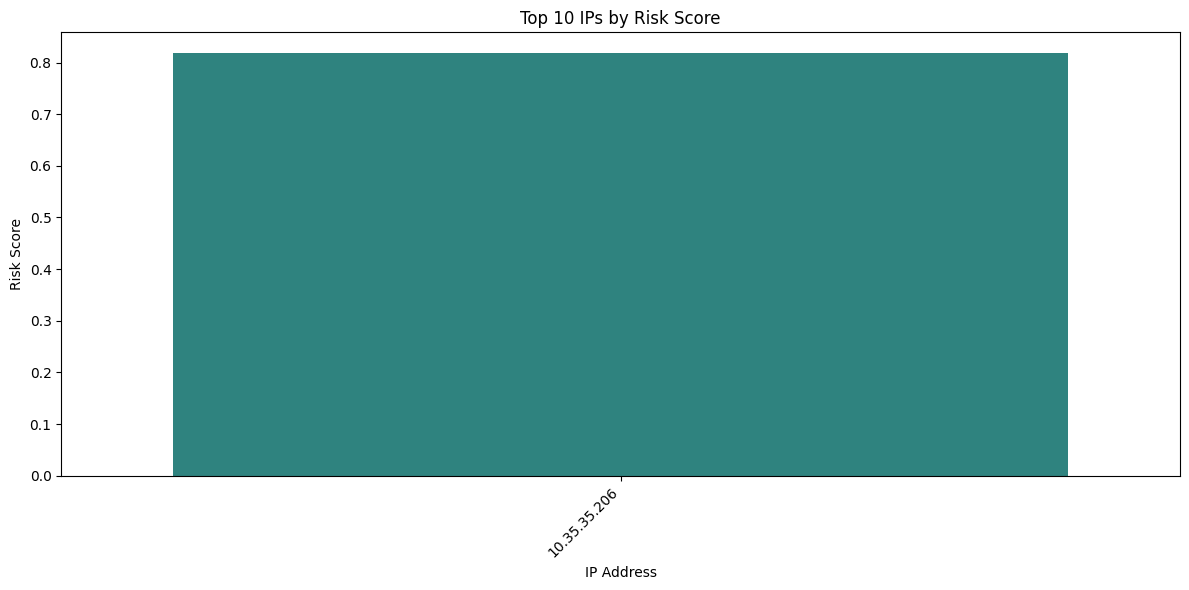

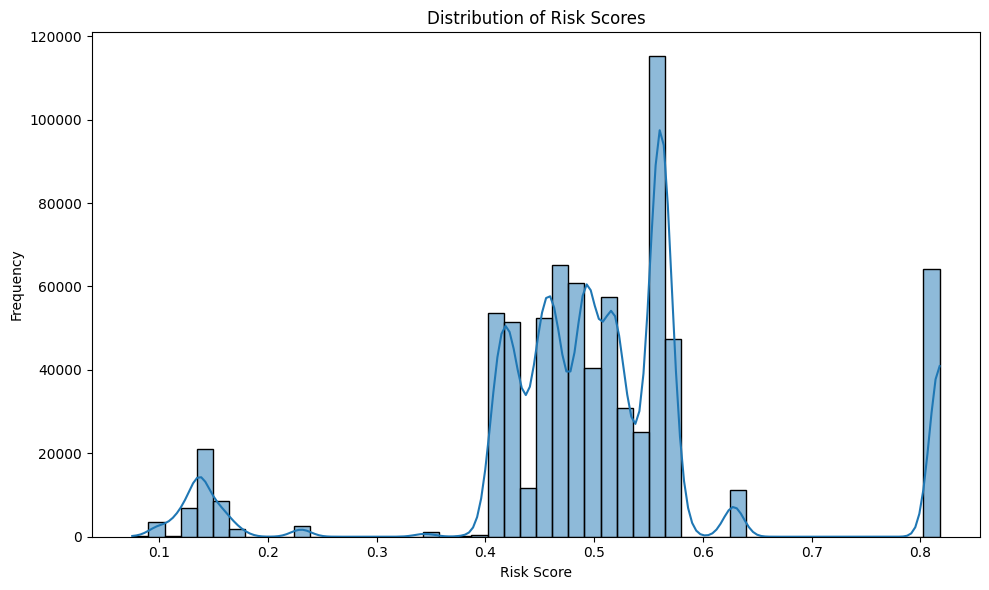

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_risk_ips.index, y=top_risk_ips['risk_score'], palette='viridis')
plt.title('Top 10 IPs by Risk Score')
plt.xlabel('IP Address')
plt.ylabel('Risk Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(ip_analysis['risk_score'], bins=50, kde=True)
plt.title('Distribution of Risk Scores')
plt.xlabel('Risk Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Part 3: Machine Learning for Alert Clustering:**

3.1 Feature Engineering:

In [ ]:
# Extract relevant features from the alerts for clustering + Perform necessary preprocessing (normalization, encoding categorical variables)


# Select potentially relevant features for clustering from AMiner
# Based on previous explorations, features like severity and temporal aspects might be useful.
# We'll use the flat dataframe for easier access to nested fields.
aminer_clustering_features = df_aminer_flat[[
    'aminer_severity', # Calculated severity score
    'LogData.DetectionTimestamp', # For temporal features
    'AMiner.ID', # IP address - can be encoded or used for grouping
    'AnalysisComponent.AnalysisComponentType', # Original Analysis Component Type
    'AnalysisComponent.AnalysisComponentIdentifier' # Identifier
]].copy()

# Extract temporal features from the timestamp
aminer_clustering_features['hour_of_day'] = aminer_clustering_features['LogData.DetectionTimestamp'].dt.hour
aminer_clustering_features['day_of_week'] = aminer_clustering_features['LogData.DetectionTimestamp'].dt.dayofweek

# Drop the original timestamp column after extracting features
aminer_clustering_features = aminer_clustering_features.drop(columns=['LogData.DetectionTimestamp'])

# Handle potential missing values (e.g., fill with 0 or a median/mean for numerical; mode for categorical)
# For now, let's fill numerical NaNs with 0 and categorical NaNs with 'Unknown'
aminer_clustering_features['aminer_severity'] = aminer_clustering_features['aminer_severity'].fillna(0)
aminer_clustering_features['hour_of_day'] = aminer_clustering_features['hour_of_day'].fillna(0)
aminer_clustering_features['day_of_week'] = aminer_clustering_features['day_of_week'].fillna(0)
aminer_clustering_features['AMiner.ID'] = aminer_clustering_features['AMiner.ID'].fillna('Unknown')
aminer_clustering_features['AnalysisComponent.AnalysisComponentType'] = aminer_clustering_features['AnalysisComponent.AnalysisComponentType'].fillna('Unknown')
aminer_clustering_features['AnalysisComponent.AnalysisComponentIdentifier'] = aminer_clustering_features['AnalysisComponent.AnalysisComponentIdentifier'].fillna(-1) # Using -1 for unknown identifier

print("AMiner Features for Clustering (first 5 rows):")
display(aminer_clustering_features.head())

print("\nAMiner Features for Clustering (info):")
aminer_clustering_features.info()

AMiner Features for Clustering (first 5 rows):


,aminer_severity,AMiner.ID,AnalysisComponent.AnalysisComponentType,AnalysisComponent.AnalysisComponentIdentifier,hour_of_day,day_of_week
0,1.0,172.17.129.140,NewMatchPathDetector,3,0,5
1,2.0,172.17.129.140,NewMatchPathValueComboDetector,19,0,5
2,1.0,172.17.129.140,NewMatchPathDetector,3,0,5
3,2.0,172.17.129.140,NewMatchPathValueComboDetector,25,0,5
4,1.0,172.17.129.140,NewMatchPathDetector,3,0,5



AMiner Features for Clustering (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55558 entries, 0 to 55557
Data columns (total 6 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   aminer_severity                                55558 non-null  float64
 1   AMiner.ID                                      55558 non-null  object 
 2   AnalysisComponent.AnalysisComponentType        55558 non-null  object 
 3   AnalysisComponent.AnalysisComponentIdentifier  55558 non-null  int64  
 4   hour_of_day                                    55558 non-null  int32  
 5   day_of_week                                    55558 non-null  int32  
dtypes: float64(1), int32(2), int64(1), object(2)
memory usage: 2.1+ MB


In [ ]:
# Select potentially relevant features for clustering from Wazuh
# Similar to AMiner, we'll use severity, temporal information, and potentially other fields.
wazuh_clustering_features = df_wazuh_flat[[
    'wazuh_severity', # Calculated severity score
    '@timestamp', # For temporal features
    'agent.ip', # Source IP address
    'rule.level', # Original rule level
    'rule.description', # Rule description - can be encoded or used for analysis
    'predecoder.program_name', # Program name
    'decoder.name' # Decoder name
]].copy()

# Extract temporal features from the timestamp
wazuh_clustering_features['hour_of_day'] = wazuh_clustering_features['@timestamp'].dt.hour
wazuh_clustering_features['day_of_week'] = wazuh_clustering_features['@timestamp'].dt.dayofweek

# Drop the original timestamp column
wazuh_clustering_features = wazuh_clustering_features.drop(columns=['@timestamp'])

# Handle potential missing values
wazuh_clustering_features['wazuh_severity'] = wazuh_clustering_features['wazuh_severity'].fillna(0)
wazuh_clustering_features['hour_of_day'] = wazuh_clustering_features['hour_of_day'].fillna(0)
wazuh_clustering_features['day_of_week'] = wazuh_clustering_features['day_of_week'].fillna(0)
wazuh_clustering_features['agent.ip'] = wazuh_clustering_features['agent.ip'].fillna('Unknown')
wazuh_clustering_features['rule.level'] = wazuh_clustering_features['rule.level'].fillna(-1) # Using -1 for unknown level
wazuh_clustering_features['rule.description'] = wazuh_clustering_features['rule.description'].fillna('Unknown')
wazuh_clustering_features['predecoder.program_name'] = wazuh_clustering_features['predecoder.program_name'].fillna('Unknown')
wazuh_clustering_features['decoder.name'] = wazuh_clustering_features['decoder.name'].fillna('Unknown')

print("Wazuh Features for Clustering (first 5 rows):")
display(wazuh_clustering_features.head())

print("\nWazuh Features for Clustering (info):")
wazuh_clustering_features.info()

Wazuh Features for Clustering (first 5 rows):


,wazuh_severity,agent.ip,rule.level,rule.description,predecoder.program_name,decoder.name,hour_of_day,day_of_week
0,3.0,172.17.131.81,3,ClamAV database update,freshclam,freshclam,2,5
1,3.0,192.168.128.170,3,ClamAV database update,freshclam,freshclam,2,5
2,3.0,172.17.131.81,3,ClamAV database update,freshclam,freshclam,2,5
3,3.0,172.17.131.81,3,ClamAV database update,freshclam,freshclam,2,5
4,3.0,172.17.131.81,3,ClamAV database update,freshclam,freshclam,2,5



Wazuh Features for Clustering (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 698231 entries, 0 to 698230
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   wazuh_severity           698231 non-null  float64
 1   agent.ip                 698231 non-null  object 
 2   rule.level               698231 non-null  int64  
 3   rule.description         698231 non-null  object 
 4   predecoder.program_name  698231 non-null  object 
 5   decoder.name             698231 non-null  object 
 6   hour_of_day              698231 non-null  int32  
 7   day_of_week              698231 non-null  int32  
dtypes: float64(1), int32(2), int64(1), object(4)
memory usage: 37.3+ MB


Justify your choice of features based on security relevance :

For aminer_clustering_features we select :
1. The aminer_severity because it has the score  for higher severity level.
2. LogData.DetectionTimestamp	to know the time of the acction that happened.
3. AMiner.ID wich is the ip address for that acction .
4. AnalysisComponent.AnalysisComponentType because the type of analysis component that generated the alert .
5. AnalysisComponent.AnalysisComponentIdentifier The idea for choose this column that alerts with the same identifier likely originate from the same specific detection rule or mechanism within AMiner By including this identifier, the clustering algorithm can potentially group together alerts that are triggered by the same underlying logic.

For wazuh_clustering_features we select :
1. We choose wazuh_severity column where higher numbers consistently indicate a higher severity level, making it easier to compare and analyze the severity of different Wazuh alerts .
2. And the agent.ip for source ip for that actions.
3. And the @timestamp for time to that actions.
4. The rule.level also where it is a standard concept in Wazuh, where rules are assigned levels from 1 to 15, with higher numbers indicating more critical alerts ( the wazuh_severity column you created incorporates this rule.level information to provide a unified severity score alongside the data.alert.severity field.
) .
5. The column rule.description have the rule description .   
6. predecoder.program_name have Program name .
7. decoder.name is the Decoder name .



---



 3.2 Clustering Implementation:

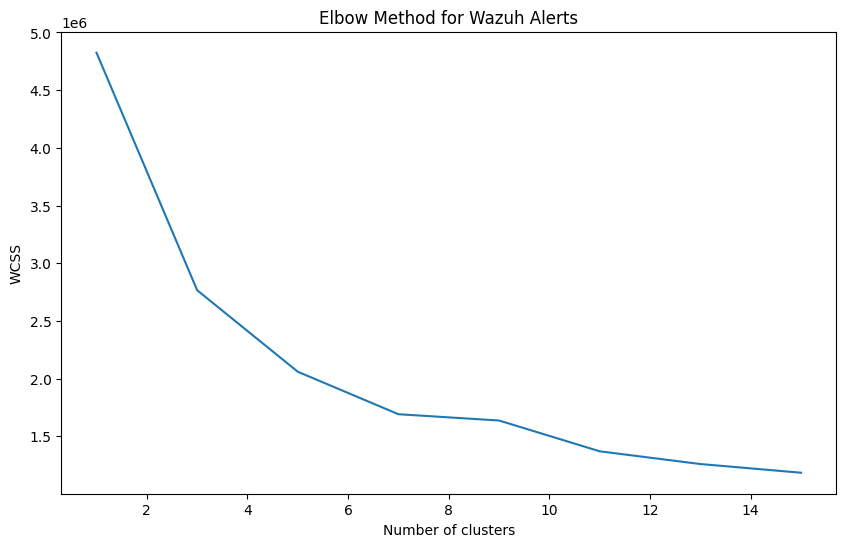

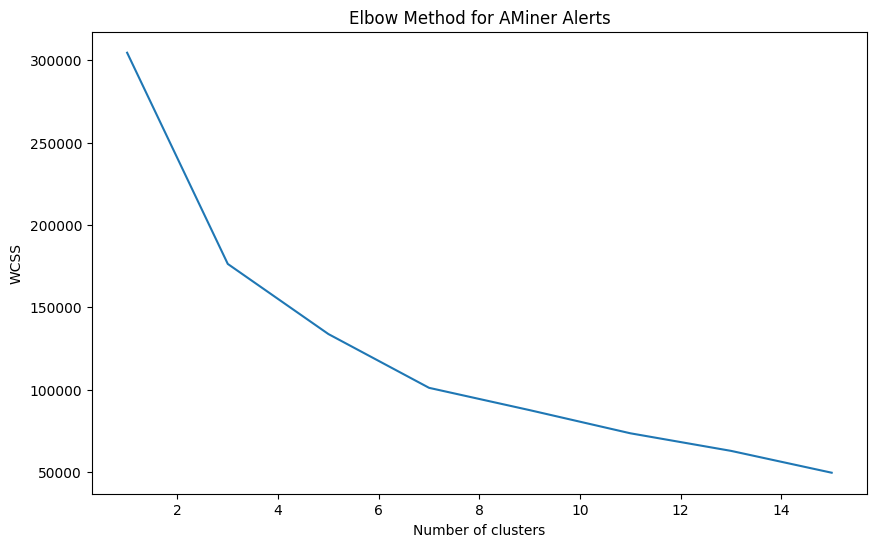

In [ ]:
# Elbow method
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify categorical and numerical features for Wazuh
wazuh_categorical_features = ['agent.ip', 'rule.description', 'predecoder.program_name', 'decoder.name']
wazuh_numerical_features = ['wazuh_severity', 'rule.level', 'hour_of_day', 'day_of_week']

# Create a preprocessing pipeline for Wazuh data
wazuh_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), wazuh_numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), wazuh_categorical_features)
    ])

# Create a pipeline with preprocessing and KMeans for Wazuh
wazuh_pipeline = Pipeline(steps=[('preprocessor', wazuh_preprocessor),
                               ('kmeans', KMeans(init='k-means++', random_state=42))])

# Apply preprocessing and calculate WCSS for different numbers of clusters for Wazuh
wscc1 = []
# Limit the range of k for performance, especially with one-hot encoding
for k in range(1, 16, 2):
    wazuh_pipeline.set_params(kmeans__n_clusters=k)
    wazuh_pipeline.fit(wazuh_clustering_features)
    wscc1.append(wazuh_pipeline.named_steps['kmeans'].inertia_)

# Plot the Elbow Method for Wazuh
plt.figure(figsize=(10, 6))
plt.plot(range(1, 16, 2), wscc1)
plt.title('Elbow Method for Wazuh Alerts')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# Identify categorical and numerical features for AMiner
aminer_categorical_features = ['AMiner.ID', 'AnalysisComponent.AnalysisComponentType']
aminer_numerical_features = ['aminer_severity', 'AnalysisComponent.AnalysisComponentIdentifier', 'hour_of_day', 'day_of_week']

# Create a preprocessing pipeline for AMiner data
aminer_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), aminer_numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), aminer_categorical_features)
    ])

# Create a pipeline with preprocessing and KMeans for AMiner
aminer_pipeline = Pipeline(steps=[('preprocessor', aminer_preprocessor),
                               ('kmeans', KMeans(init='k-means++', random_state=42))])

# Apply preprocessing and calculate WCSS for different numbers of clusters for AMiner
wscc2 = []
# Limit the range of k for performance
for k in range(1, 16, 2):
    aminer_pipeline.set_params(kmeans__n_clusters=k)
    aminer_pipeline.fit(aminer_clustering_features)
    wscc2.append(aminer_pipeline.named_steps['kmeans'].inertia_)

# Plot the Elbow Method for AMiner
plt.figure(figsize=(10, 6))
plt.plot(range(1, 16, 2), wscc2)
plt.title('Elbow Method for AMiner Alerts')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
# The suitable number of cluster of AMiner data is 7, and Wazuh is 7
aminer_pipeline.set_params(kmeans__n_clusters=7)
aminer_pipeline.fit(aminer_clustering_features)
y_means_aminer = aminer_pipeline.predict(aminer_clustering_features)
aminer_clustering_features['cluster'] = y_means_aminer

wazuh_pipeline.set_params(kmeans__n_clusters=7)
wazuh_pipeline.fit(wazuh_clustering_features)
y_means_wazuh = wazuh_pipeline.predict(wazuh_clustering_features)
wazuh_clustering_features['cluster'] = y_means_wazuh

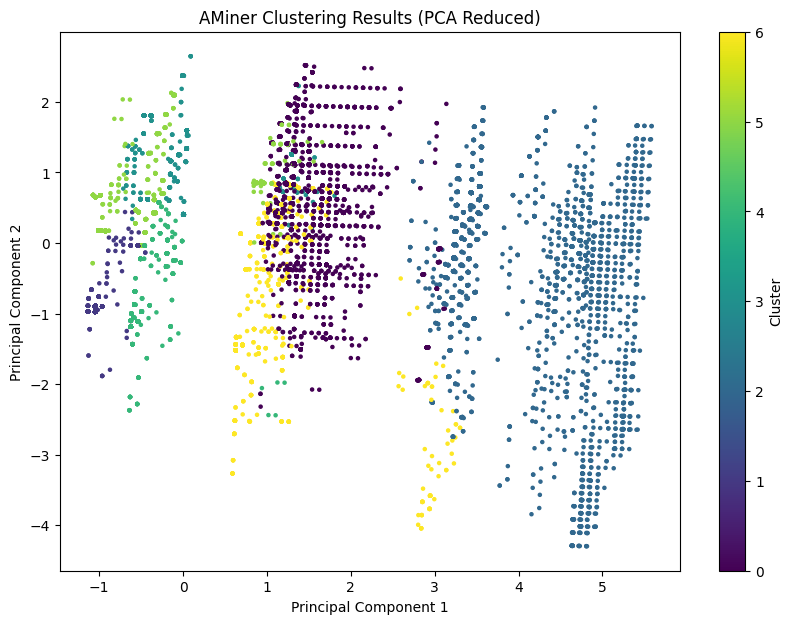

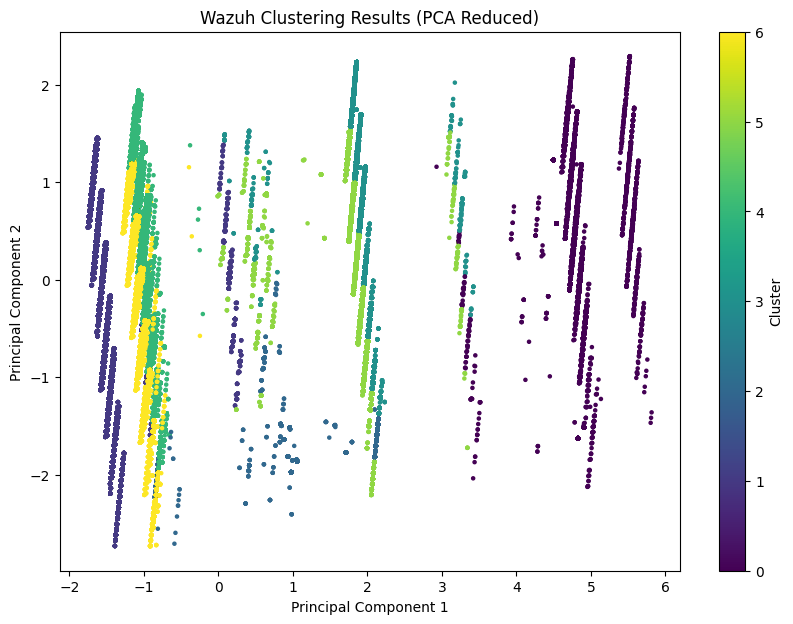

In [ ]:
from sklearn.decomposition import PCA

aminer_features_transformed = aminer_pipeline.named_steps['preprocessor'].transform(aminer_clustering_features.drop(columns=['cluster']))


pca = PCA(n_components=2)
aminer_pca_components = pca.fit_transform(aminer_features_transformed)

# Create a scatter plot using the PCA components, colored by cluster
plt.figure(figsize=(10, 7))
plt.scatter(aminer_pca_components[:, 0], aminer_pca_components[:, 1], c=aminer_clustering_features['cluster'], cmap='viridis', s=5)
plt.title('AMiner Clustering Results (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()

wazuh_features_transformed = wazuh_pipeline.named_steps['preprocessor'].transform(wazuh_clustering_features.drop(columns=['cluster']))

pca_wazuh = PCA(n_components=2)
wazuh_pca_components = pca_wazuh.fit_transform(wazuh_features_transformed)

plt.figure(figsize=(10, 7))
plt.scatter(wazuh_pca_components[:, 0], wazuh_pca_components[:, 1], c=wazuh_clustering_features['cluster'], cmap='viridis', s=5)
plt.title('Wazuh Clustering Results (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()

3.3 Cluster Interpretation:

In [ ]:
# Display the head of each cluster for AMiner
for cluster_id in sorted(aminer_clustering_features['cluster'].unique()):
    print(f"\n--- AMiner Cluster {cluster_id} ---")
    display(aminer_clustering_features[aminer_clustering_features['cluster'] == cluster_id].head())

# Display the head of each cluster for Wazuh
for cluster_id in sorted(wazuh_clustering_features['cluster'].unique()):
    print(f"\n--- Wazuh Cluster {cluster_id} ---")
    display(wazuh_clustering_features[wazuh_clustering_features['cluster'] == cluster_id].head())


--- AMiner Cluster 0 ---


,aminer_severity,AMiner.ID,AnalysisComponent.AnalysisComponentType,AnalysisComponent.AnalysisComponentIdentifier,hour_of_day,day_of_week,cluster
1,2.0,172.17.129.140,NewMatchPathValueComboDetector,19,0,5,0
3,2.0,172.17.129.140,NewMatchPathValueComboDetector,25,0,5,0
5,2.0,172.17.129.140,NewMatchPathValueComboDetector,16,0,5,0
7,2.0,172.17.129.140,NewMatchPathValueComboDetector,18,0,5,0
10,0.0,192.168.255.254,NewMatchPathValueDetector,27,0,5,0



--- AMiner Cluster 1 ---


,aminer_severity,AMiner.ID,AnalysisComponent.AnalysisComponentType,AnalysisComponent.AnalysisComponentIdentifier,hour_of_day,day_of_week,cluster
730,0.0,10.35.35.206,NewMatchPathValueDetector,4,12,5,1
731,0.0,172.17.129.140,NewMatchPathValueDetector,5,13,5,1
742,0.0,172.17.129.140,NewMatchPathValueDetector,4,21,5,1
840,0.0,172.17.129.140,NewMatchPathValueDetector,4,13,0,1
841,0.0,172.17.130.37,NewMatchPathValueDetector,4,13,0,1



--- AMiner Cluster 2 ---


...

,wazuh_severity,agent.ip,rule.level,rule.description,predecoder.program_name,decoder.name,hour_of_day,day_of_week,cluster
0,3.0,172.17.131.81,3,ClamAV database update,freshclam,freshclam,2,5,4
1,3.0,192.168.128.170,3,ClamAV database update,freshclam,freshclam,2,5,4
2,3.0,172.17.131.81,3,ClamAV database update,freshclam,freshclam,2,5,4
3,3.0,172.17.131.81,3,ClamAV database update,freshclam,freshclam,2,5,4
4,3.0,172.17.131.81,3,ClamAV database update,freshclam,freshclam,2,5,4



--- Wazuh Cluster 5 ---


,wazuh_severity,agent.ip,rule.level,rule.description,predecoder.program_name,decoder.name,hour_of_day,day_of_week,cluster
3728,6.0,10.35.32.1,6,IDS event.,Unknown,snort,12,5,5
3729,6.0,10.35.32.1,6,IDS event.,Unknown,snort,12,5,5
3731,6.0,10.35.32.1,6,IDS event.,Unknown,snort,12,5,5
3734,6.0,10.35.32.1,6,IDS event.,Unknown,snort,12,5,5
3735,6.0,10.35.32.1,6,IDS event.,Unknown,snort,12,5,5



--- Wazuh Cluster 6 ---


,wazuh_severity,agent.ip,rule.level,rule.description,predecoder.program_name,decoder.name,hour_of_day,day_of_week,cluster
3727,3.0,10.35.32.1,3,Suricata: Alert - SURICATA TLS invalid record/...,Unknown,json,12,5,6
3730,3.0,10.35.32.1,3,Suricata: Alert - SURICATA TLS invalid handsha...,Unknown,json,12,5,6
3732,3.0,10.35.32.1,3,Suricata: Alert - SURICATA TLS invalid handsha...,Unknown,json,12,5,6
3733,3.0,10.35.32.1,3,Suricata: Alert - SURICATA TLS invalid record/...,Unknown,json,12,5,6
3736,3.0,10.35.32.1,3,Suricata: Alert - SURICATA TLS invalid handsha...,Unknown,json,12,5,6


In [ ]:
for cluster_id in sorted(aminer_clustering_features['cluster'].unique()):
    print(f"\n--- AMiner Cluster {cluster_id} ---")
    print(aminer_clustering_features[aminer_clustering_features['cluster'] == cluster_id]['AnalysisComponent.AnalysisComponentType'].value_counts())
    print(aminer_clustering_features[aminer_clustering_features['cluster'] == cluster_id]['AnalysisComponent.AnalysisComponentIdentifier'].value_counts())
    print(aminer_clustering_features[aminer_clustering_features['cluster'] == cluster_id]['aminer_severity'].describe())



--- AMiner Cluster 0 ---
AnalysisComponent.AnalysisComponentType
NewMatchPathValueDetector         1569
NewMatchPathValueComboDetector    1420
CharsetDetector                    121
Name: count, dtype: int64
AnalysisComponent.AnalysisComponentIdentifier
27    1569
19     356
20     303
15     150
14     143
29     121
18      77
25      77
23      63
22      63
16      50
28      48
24      28
17      21
21      18
26      16
13       7
Name: count, dtype: int64
count    3110.000000
mean        1.029904
std         1.056497
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max         3.000000
Name: aminer_severity, dtype: float64

--- AMiner Cluster 1 ---
AnalysisComponent.AnalysisComponentType
NewMatchPathValueDetector    13511
Name: count, dtype: int64
AnalysisComponent.AnalysisComponentIdentifier
5    11935
4     1576
Name: count, dtype: int64
count    13511.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%

In [ ]:
for cluster_id in sorted(wazuh_clustering_features['cluster'].unique()):
    print(f"\n--- Wazuh Cluster {cluster_id} ---")
    print(wazuh_clustering_features[wazuh_clustering_features['cluster'] == cluster_id]['rule.description'].value_counts())
    print(wazuh_clustering_features[wazuh_clustering_features['cluster'] == cluster_id]['rule.level'].describe())



--- Wazuh Cluster 0 ---
rule.description
Multiple web server 400 error codes from same source ip.                     5868
Multiple IDS alerts for same id.                                             4866
Multiple IDS events from same source ip.                                     1454
Multiple IDS alerts for same id (ignoring now this id).                      1013
First time this IDS alert is generated.                                       119
Multiple IDS events from same source ip (ignoring now this srcip and id).     109
PAM: Multiple failed logins in a small period of time.                         48
Dovecot brute force attack (multiple auth failures).                           31
CMS (WordPress or Joomla) brute force attempt.                                  1
Name: count, dtype: int64
count    13509.000000
mean        10.065290
std          0.338132
min          8.000000
25%         10.000000
50%         10.000000
75%         10.000000
max         11.000000
Name: rule.level, 

--------------------------------------------------------------

**AMiner Clusters Overview:**

AMiner Cluster 0 – Mixed Detection with Moderate Severity

- Detector Types: Dominated by NewMatchPathValueDetector and NewMatchPathValueComboDetector.

- Component Identifiers: Many distinct IDs (27, 19, 20...).

- Severity: Mean ~1.03

- Interpretation: A mixed cluster capturing low-to-mid severity anomalies using various detectors; likely representing general anomaly detection across diverse metrics.

AMiner Cluster 1 – Uniform, Low-Severity Signature Matches

- Detector Types: Only NewMatchPathValueDetector.

- Component Identifiers: 5 and 4.

- Severity: Constant 0 severity.

- Interpretation: Likely normal behavior or benign pattern matching with no real threat — could represent false positives or known, safe signatures.

AMiner Cluster 2 – High Severity, Statistical Anomaly Detection

- Detector Types: EntropyDetector, EventCountClusterDetector, etc.

- Component Identifiers: 30, 32, 33

- Severity: Mean ~5.56

- Interpretation: Clear signs of significant anomalies detected using statistical behavior modeling — likely associated with potential attacks (Like: data exfiltration, brute force patterns).

AMiner Cluster 3 – Diverse Content Anomalies, Mostly Low Severity

- Detector Types: Mix of NewMatchPathValueDetector, NewMatchPathDetector, and CharsetDetector.

- Component Identifiers: Wide range (3, 5, 7).

- Severity: Mean ~0.76.

- Interpretation: This could indicate benign variations or less critical anomalies, especially in protocol or content structure.

AMiner Cluster 4 – Focused Path Anomalies with Constant Medium Severity

- Detector Types: Primarily NewMatchPathDetector.

- Component Identifiers: 3.

- Severity: Constant around 1.

- Interpretation: Consistent, specific type of anomaly, likely involving file path behavior changes or application-level scanning attempts.

AMiner Cluster 5 – High Volume of Low-Severity Matches

- Detector Types: Mostly NewMatchPathValueDetector, with some entropy-based ones.

- Component Identifiers: 5 and 3.

- Severity: Mean ~0.2.

- Interpretation: Probably signature-based detections with low severity and high frequency — likely benign or routine detections, but could include noise.

AMiner Cluster 6 – Charset & Entropy Anomalies, Moderate Severity

- Detector Types: Mostly CharsetDetector, with entropy/statistical detectors.

- Component Identifiers: 6, 7, 9

- Severity: Mean ~3.05.

- Interpretation: Character encoding anomalies or statistical outliers — likely related to malformed or obfuscated payloads ( encoding attacks or evasion attempts).

**Wazuh Clusters Overview:**

Wazuh Cluster 0 – Repetitive IDS/Web Alerts with High Severity

- Alerts: 400 errors, brute force, repeated IDS alerts.

- Level: Mean ~10.

- Interpretation: High confidence attack activity, likely brute force attempts, scanning, or repeated probing from the same source.

Wazuh Cluster 1 – Mostly Benign Email Logins

- Alerts: Dovecot authentication success, ClamAV updates.

- Level: Constant 3.

- Interpretation: Low-risk, normal operations — system login and AV update events.

Wazuh Cluster 2 – Web Errors, Suspicious Access

- Alerts: 400 errors, forbidden access, suspicious URLs.

- Level: Mean ~5.

- Interpretation: Indicates probing, misconfigurations, or minor reconnaissance. Likely an early stage of scanning or vulnerability testing.

Wazuh Cluster 3 – High Volume IDS Events

- Alerts: IDS events and login failures.

- Level: Mean ~6.

- Interpretation: Active attack attempts, possibly automated tools or credential stuffing.

Wazuh Cluster 4 – Suricata Alerts (TLS/Domain-related)

- Alerts: TLS errors, suspicious domains, COVID-related domains.

- Level: Constant ~3.

- Interpretation: Potential C2 communication, evasion, or reconnaissance — very specific Suricata detections that may indicate staged intrusion attempts.

Wazuh Cluster 5 – Heavy IDS and Web Probing

- Alerts: IDS events, login failures, suspicious URLs.

- Level: Mean ~5.9.

- Interpretation: Combination of intrusion attempts and authentication brute force, possibly by more aggressive or persistent attackers.

Wazuh Cluster 6 – Suricata TLS/HTTP/Domain Issues

- Alerts: TLS handshake/record errors, .biz/.cloud DNS queries.

- Level: Constant ~3.

- Interpretation: Likely malware beacons, encrypted C2 traffic, or evasion techniques observed by Suricata.



---




Summary Tables:

--------------------------------------------------------------
- Cluster -----	AMiner Summary

0 -----	Mixed moderate-severity anomalies across multiple detectors

1 -----	Constant low severity; likely benign signature detections

2 -----	High-severity statistical anomalies (potential attacks)

3 -----	Low severity content structure anomalies.

4 -----	Consistent path anomalies with fixed medium severity

5 -----	High-frequency, low-severity benign anomalies

6 -----	Charset/statistical anomalies with moderate severity

--------------------------------------------------------------
- Cluster -----	Wazuh Summary


0 -----	Repetitive IDS/web brute-force events (high severity)

1 -----	Low-severity normal email/login events

2 -----	Suspicious access attempts and web errors

3 -----	High-volume IDS alerts, credential attempts

4 -----	Suricata domain/TLS anomalies (potential evasion)

5 -----	Mix of intrusion + login failures (mid-high severity)

6 -----	Suricata-based TLS and domain scanning detections

--------------------------------------------------------------

--------------------------------------------------------------

In [ ]:
from sklearn.metrics import silhouette_score

# Silhouette Score for AMiner
aminer_silhouette = silhouette_score(aminer_features_transformed, aminer_clustering_features['cluster'])
print(f"AMiner Silhouette Score: {aminer_silhouette:.3f}")

AMiner Silhouette Score: 0.431


**Interpretation of the result of Silhouette Score:**

"*In log/text alert clustering tasks, a Silhouette Score of around 0.3–0.5 is often deemed acceptable due to the noisy nature and high textual similarity of the alerts, as supported by literature in cybersecurity log clustering (e.g., Landauer et al., 2020).*"



---



**Suggestions in a SOC Environment:**


Integration Pipeline:

- Input: Real-time Suricata/AMiner/Wazuh logs.

- Preprocessing: Text cleaning, TF-IDF vectorization.

- Clustering: Apply KMeans (pre-trained model or online updates).

- Output: Cluster ID attached to each alert.

SOC Dashboard View:

- Present clusters as grouped incidents.

- Show: Cluster summary keywords & Representative alert samples & Number of alerts in the cluster & Severity scores

Analyst Workflow:

- Analysts triage alerts by reviewing cluster summaries instead of individual alerts.

- Mark entire clusters as: Benign or Known threat or Escalate for deeper review

Automation Potential:

- Set rules for auto-handling low-severity clusters (for example: repeated port scans).

- Apply supervised learning to classify clusters by attack type or urgency.

Feedback Loop:

- Analysts give feedback on clusters (correct/incorrect).

- Periodically retrain clustering with updated labeled data to improve accuracy.

--------------------------------------------------------------